In [1]:
import numpy as np
import pandas as pd

In [45]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("irecsys/itmrec")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/itmrec


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ====================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ====================================================

# Настройка визуализаций
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Загрузка основных данных
print("="*50)
print("ЗАГРУЗКА ДАТАСЕТА ITM-REC")
print("="*50)

# Основные файлы
ratings = pd.read_csv('/kaggle/input/itmrec/ratings.csv')
users = pd.read_csv('/kaggle/input/itmrec/users.csv')
items = pd.read_csv('/kaggle/input/itmrec/items.csv')
group_ratings = pd.read_csv('/kaggle/input/itmrec/group_ratings.csv')

print(f"\nРазмеры загруженных таблиц:")
print(f"- ratings: {ratings.shape}")
print(f"- users: {users.shape}")
print(f"- items: {items.shape}")
print(f"- group_ratings: {group_ratings.shape}")

# Базовый осмотр рейтингов
print("\n" + "="*50)
print("БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*50)

print("\n1. Первые 5 строк таблицы ratings:")
display(ratings.head())

print("\n2. Информация о типах данных и пропусках:")
ratings.info()

print("\n3. Базовая статистика числовых колонок:")
display(ratings.describe().round(2))

# Проверка уникальных значений
print("\n4. Уникальные значения в ключевых колонках:")
print(f"Уникальных пользователей: {ratings['UserID'].nunique()}")
print(f"Уникальных тем проектов: {ratings['Item'].nunique()}")
print(f"Семестры: {ratings['Semester'].unique()}")
print(f"Классы (специализации): {ratings['Class'].unique()}")
print(f"Периоды COVID: {ratings['Lockdown'].unique()}")

ЗАГРУЗКА ДАТАСЕТА ITM-REC

Размеры загруженных таблиц:
- ratings: (5230, 9)
- users: (476, 4)
- items: (70, 4)
- group_ratings: (1117, 9)

БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ

1. Первые 5 строк таблицы ratings:


,UserID,Item,Rating,App,Data,Ease,Class,Semester,Lockdown
0,1173,28,5,4,4.0,4,DA,Fall,PRE
1,1173,41,5,4,4.0,4,DA,Fall,PRE
2,1173,61,4,4,4.0,4,DA,Fall,PRE
3,1173,22,1,1,2.0,2,DA,Fall,PRE
4,1173,27,1,1,2.0,2,DA,Fall,PRE



2. Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5230 entries, 0 to 5229
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   UserID    5230 non-null   int64  
 1   Item      5230 non-null   int64  
 2   Rating    5230 non-null   int64  
 3   App       5230 non-null   int64  
 4   Data      5228 non-null   float64
 5   Ease      5230 non-null   int64  
 6   Class     5230 non-null   object 
 7   Semester  5230 non-null   object 
 8   Lockdown  5230 non-null   object 
dtypes: float64(1), int64(5), object(3)
memory usage: 367.9+ KB

3. Базовая статистика числовых колонок:


,UserID,Item,Rating,App,Data,Ease
count,5230.00,5230.00,5230.00,5230.00,5228.00,5230.00
mean,1248.54,36.58,3.37,3.42,3.39,3.18
std,141.91,18.51,1.44,1.29,1.22,1.13
min,1000.00,1.00,1.00,1.00,1.00,1.00
25%,1128.00,23.00,2.00,2.00,3.00,2.00
50%,1251.50,34.00,4.00,4.00,4.00,3.00
75%,1373.00,51.00,5.00,4.00,4.00,4.00
max,1492.00,70.00,5.00,5.00,5.00,5.00



4. Уникальные значения в ключевых колонках:
Уникальных пользователей: 454
Уникальных тем проектов: 70
Семестры: ['Fall' 'Spring']
Классы (специализации): ['DA' 'DB' 'DM']
Периоды COVID: ['PRE' 'DUR' 'POS']


In [47]:
# Заполнение пропусков
ratings['Data'].fillna(ratings['Data'].median(), inplace=True)


АНАЛИЗ РАСПРЕДЕЛЕНИЙ РЕЙТИНГОВ


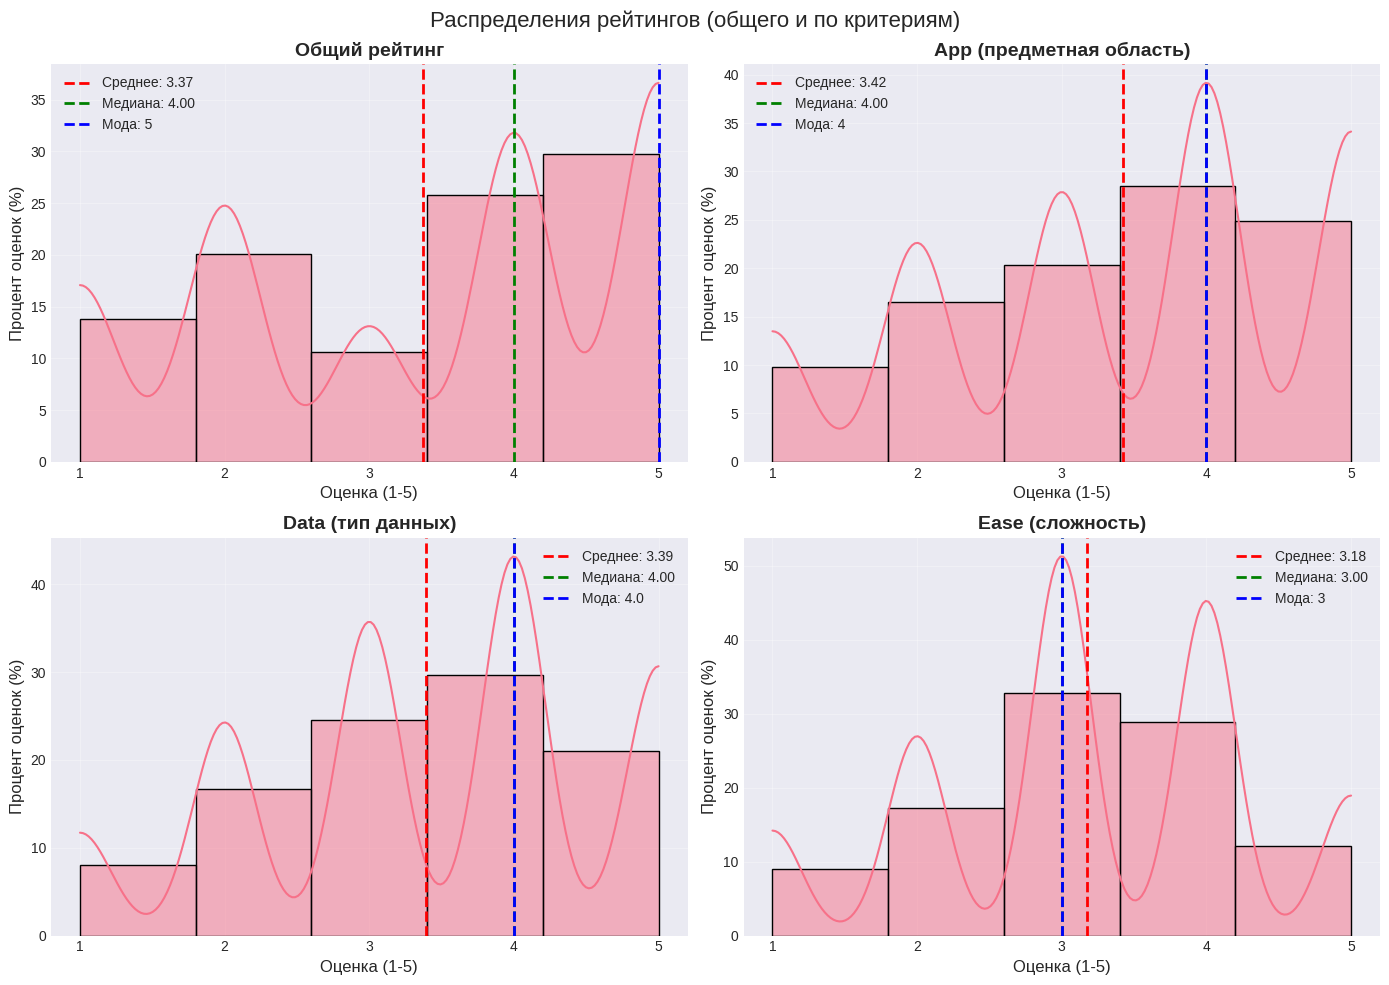


Средние значения рейтингов:
- Rating: 3.374 ± 1.435
- App: 3.421 ± 1.289
- Data: 3.390 ± 1.215
- Ease: 3.177 ± 1.129


In [26]:
# ====================================================
# 2. РАСПРЕДЕЛЕНИЯ РЕЙТИНГОВ
# ====================================================

print("\n" + "="*50)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЙ РЕЙТИНГОВ")
print("="*50)

# Создаем subplot для всех распределений
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределения рейтингов (общего и по критериям)', fontsize=16)

# Список рейтингов для анализа
rating_columns = ['Rating', 'App', 'Data', 'Ease']
titles = ['Общий рейтинг', 'App (предметная область)', 
          'Data (тип данных)', 'Ease (сложность)']

for idx, (col, title) in enumerate(zip(rating_columns, titles)):
    ax = axes[idx//2, idx%2]
    
    # Гистограмма с кривой плотности
    sns.histplot(data=ratings, x=col, bins=5, kde=True, ax=ax, 
                 stat='percent', edgecolor='black')
    
    # Статистики
    mean_val = ratings[col].mean()
    median_val = ratings[col].median()
    mode_val = ratings[col].mode()[0]
    
    # Вертикальные линии для статистик
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Среднее: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2,
               label=f'Медиана: {median_val:.2f}')
    ax.axvline(mode_val, color='blue', linestyle='--', linewidth=2,
               label=f'Мода: {mode_val}')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Оценка (1-5)', fontsize=12)
    ax.set_ylabel('Процент оценок (%)', fontsize=12)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительный анализ: совместное распределение
print("\nСредние значения рейтингов:")
for col in rating_columns:
    mean_val = ratings[col].mean()
    std_val = ratings[col].std()
    print(f"- {col}: {mean_val:.3f} ± {std_val:.3f}")


КОРРЕЛЯЦИОННЫЙ АНАЛИЗ МНОГОКРИТЕРИАЛЬНЫХ ОЦЕНОК


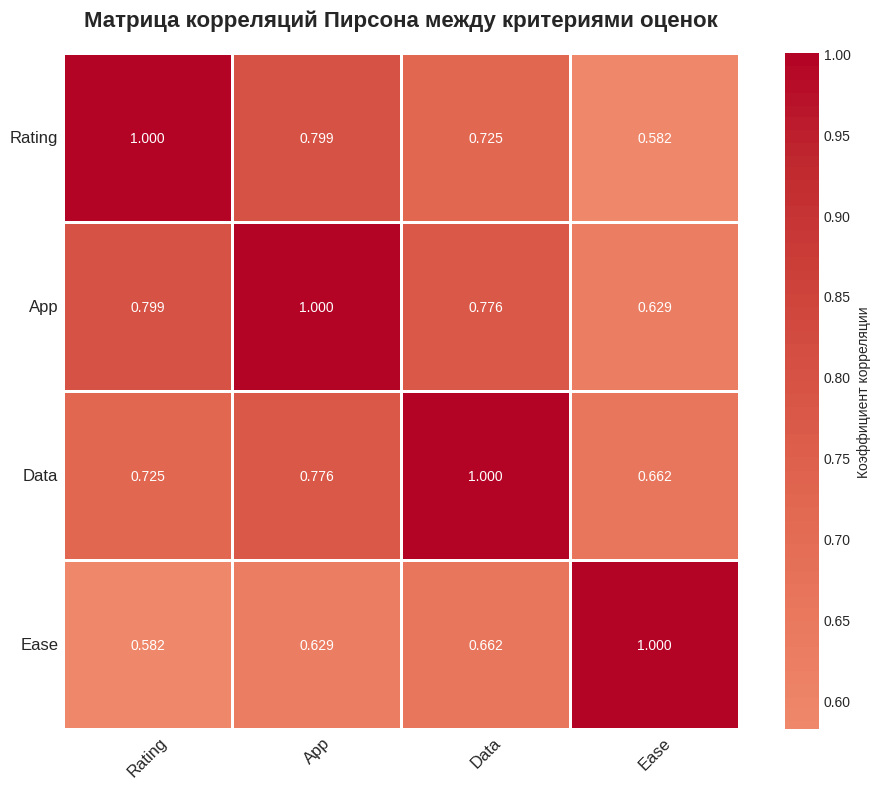


Парные зависимости между критериями:


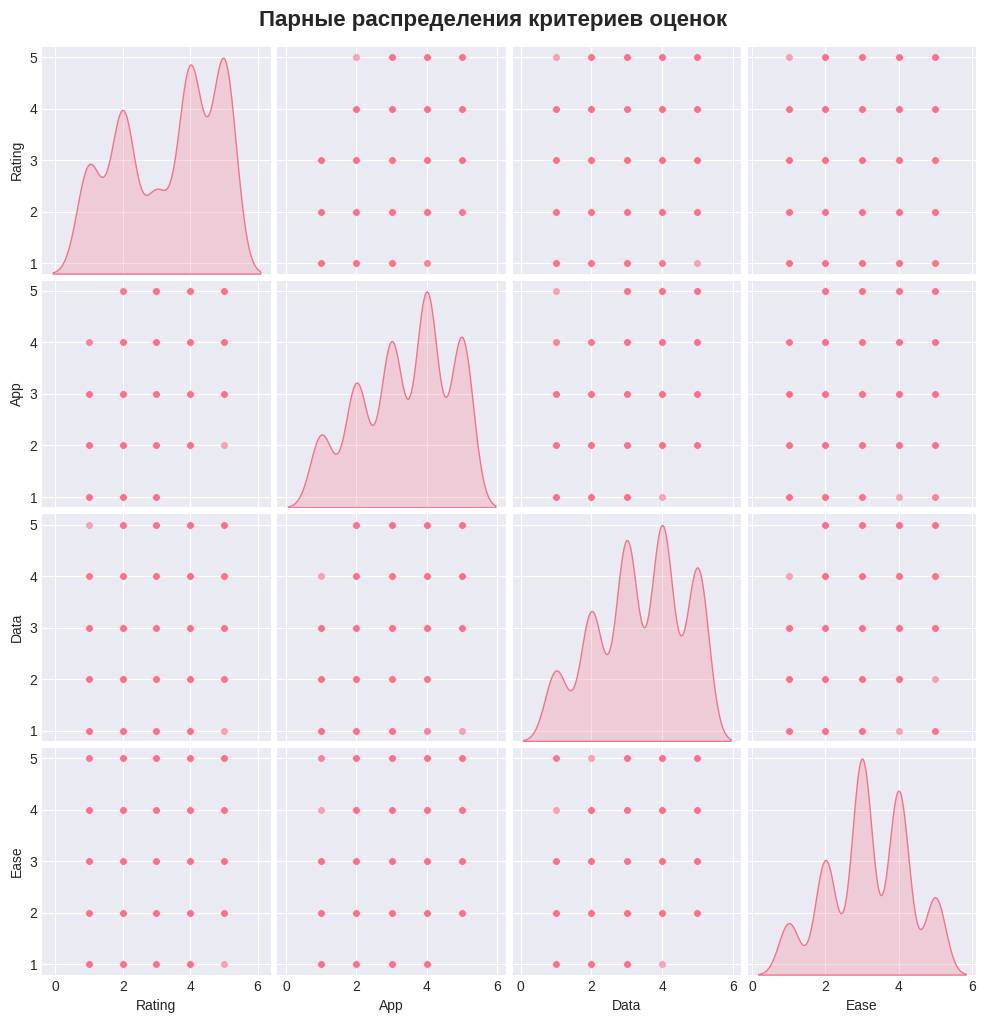


Статистическая значимость корреляций (p-value):
- Rating vs App: r = 0.7988, p = 0.0000e+00
- Rating vs Data: r = 0.7247, p = 0.0000e+00
- Rating vs Ease: r = 0.5821, p = 0.0000e+00

РЕГРЕССИОННЫЙ АНАЛИЗ ДЛЯ ПРЕДСКАЗАНИЯ ОБЩЕГО РЕЙТИНГА
Коэффициенты линейной регрессии (влияние на общий рейтинг):
- App: 0.6416
- Data: 0.2771
- Ease: 0.0824
- Intercept: -0.0221
- R² score: 0.6678


In [27]:
# ====================================================
# 3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# ====================================================

print("\n" + "="*50)
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ МНОГОКРИТЕРИАЛЬНЫХ ОЦЕНОК")
print("="*50)

# Матрица корреляций Пирсона
correlation_matrix = ratings[['Rating', 'App', 'Data', 'Ease']].corr(method='pearson')

# Визуализация heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            center=0, square=True, linewidths=1,
            fmt='.3f', cbar_kws={'label': 'Коэффициент корреляции'})

plt.title('Матрица корреляций Пирсона между критериями оценок', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# Парные графики для визуализации зависимостей
print("\nПарные зависимости между критериями:")
pairplot_data = ratings[['Rating', 'App', 'Data', 'Ease']].sample(1000)  # Для скорости

g = sns.pairplot(pairplot_data, diag_kind='kde', 
                 plot_kws={'alpha': 0.6, 's': 30},
                 diag_kws={'fill': True})
g.fig.suptitle('Парные распределения критериев оценок', 
               fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Статистический анализ корреляций
print("\nСтатистическая значимость корреляций (p-value):")
for criterion in ['App', 'Data', 'Ease']:
    corr_coef, p_value = stats.pearsonr(ratings['Rating'], ratings[criterion])
    print(f"- Rating vs {criterion}: r = {corr_coef:.4f}, p = {p_value:.4e}")

# Анализ: какой критерий лучше предсказывает общий рейтинг?
print("\n" + "="*50)
print("РЕГРЕССИОННЫЙ АНАЛИЗ ДЛЯ ПРЕДСКАЗАНИЯ ОБЩЕГО РЕЙТИНГА")
print("="*50)

from sklearn.linear_model import LinearRegression

X = ratings[
    (ratings['App'] == ratings['App']) &\
    (ratings['Data'] == ratings['Data']) &\
    (ratings['Ease'] == ratings['Ease'])
][['App', 'Data', 'Ease']]
y = ratings[
    (ratings['App'] == ratings['App']) &\
    (ratings['Data'] == ratings['Data']) &\
    (ratings['Ease'] == ratings['Ease'])
]['Rating']

model = LinearRegression()
model.fit(X, y)

print("Коэффициенты линейной регрессии (влияние на общий рейтинг):")
for col, coef in zip(['App', 'Data', 'Ease'], model.coef_):
    print(f"- {col}: {coef:.4f}")
print(f"- Intercept: {model.intercept_:.4f}")
print(f"- R² score: {model.score(X, y):.4f}")


АНАЛИЗ ВЛИЯНИЯ КОНТЕКСТНЫХ ПЕРЕМЕННЫХ


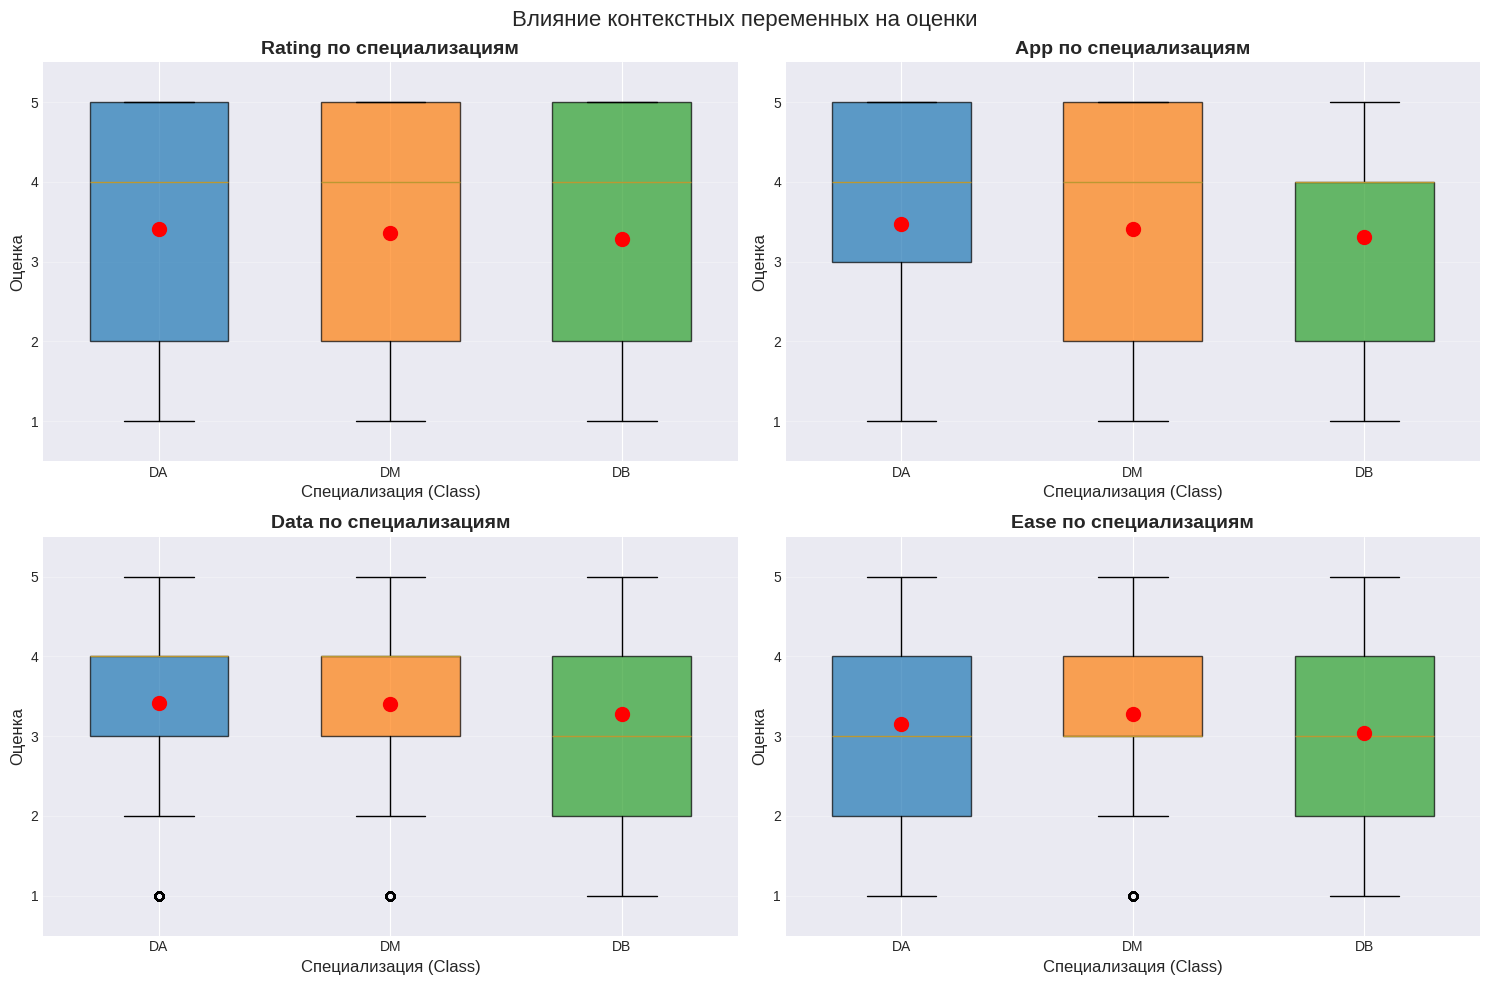


Статистический анализ различий между специализациями (ANOVA):
- Rating: F = 2.5039, p = 0.0819
- App: F = 5.1304, p = 0.0059
- Data: F = 3.9180, p = 0.0199
- Ease: F = 13.5423, p = 0.0000

------------------------------
АНАЛИЗ ВЛИЯНИЯ СЕМЕСТРА (Semester)
------------------------------


Rating                 App   Data   Ease
           mean    std count   mean   mean   mean
Semester                                         
Fall      3.388  1.432  3417  3.444  3.398  3.214
Spring    3.347  1.441  1813  3.378  3.376  3.108

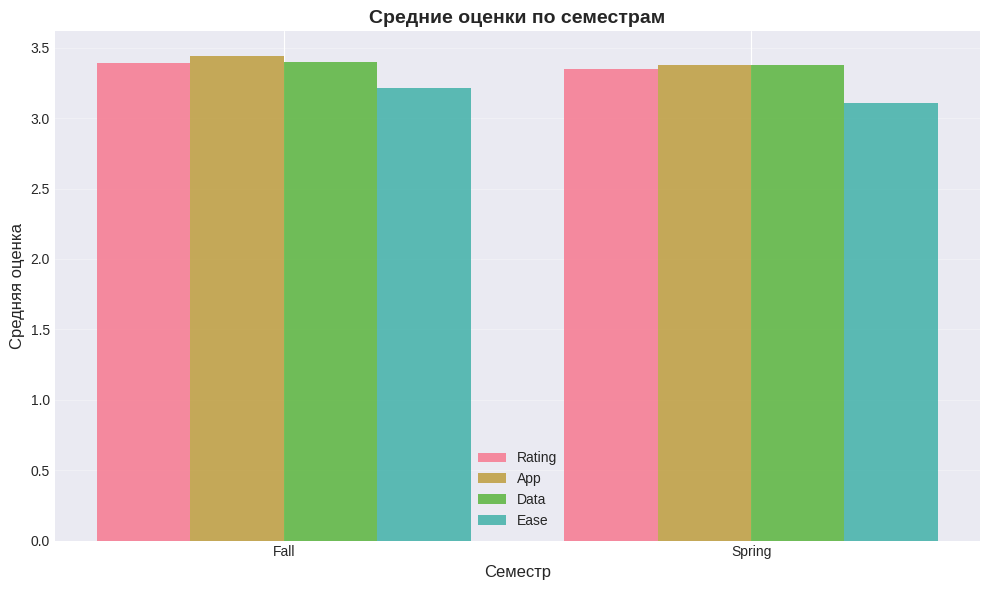


КОМБИНИРОВАННЫЙ АНАЛИЗ: Class × Semester
Средний общий рейтинг по комбинациям Class × Semester:


Semester,Fall,Spring
Class,,
DA,3.424,3.383
DB,3.247,3.402
DM,3.415,3.296



Количество оценок по комбинациям Class × Semester:


Semester,Fall,Spring
Class,,
DA,1713,823
DB,640,204
DM,1064,786


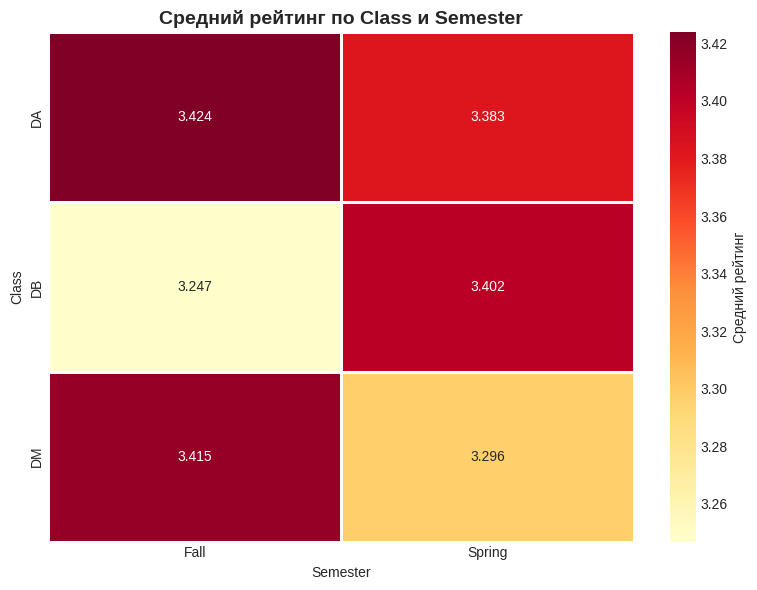

In [28]:
# ====================================================
# 4. ВЛИЯНИЕ КОНТЕКСТНЫХ ПЕРЕМЕННЫХ
# ====================================================

print("\n" + "="*50)
print("АНАЛИЗ ВЛИЯНИЯ КОНТЕКСТНЫХ ПЕРЕМЕННЫХ")
print("="*50)

# Создаем фигуру для анализа контекста
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Влияние контекстных переменных на оценки', fontsize=16)

# 4.1 Влияние специализации (Class) на оценки
class_order = ['DA', 'DM', 'DB']  # Порядок для визуализации
class_palette = {'DA': '#1f77b4', 'DM': '#ff7f0e', 'DB': '#2ca02c'}

# Boxplot для каждого критерия по Class
for idx, criterion in enumerate(['Rating', 'App', 'Data', 'Ease']):
    ax = axes[idx//2, idx%2]
    
    # Создаем DataFrame для boxplot
    plot_data = []
    for cls in class_order:
        values = ratings[ratings['Class'] == cls][criterion].values
        plot_data.append(values)
    
    # Boxplot с кастомизацией
    box = ax.boxplot(plot_data, patch_artist=True, 
                     labels=class_order, widths=0.6)
    
    # Раскрашиваем боксы
    for patch, cls in zip(box['boxes'], class_order):
        patch.set_facecolor(class_palette[cls])
        patch.set_alpha(0.7)
    
    # Настройки графика
    ax.set_title(f'{criterion} по специализациям', fontsize=14, fontweight='bold')
    ax.set_xlabel('Специализация (Class)', fontsize=12)
    ax.set_ylabel('Оценка', fontsize=12)
    ax.set_ylim(0.5, 5.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавляем средние значения
    for i, cls in enumerate(class_order):
        mean_val = ratings[ratings['Class'] == cls][criterion].mean()
        ax.scatter(i+1, mean_val, color='red', s=100, zorder=5, 
                  label='Среднее' if i == 0 else None)

plt.tight_layout()
plt.show()

# 4.2 Статистический анализ различий между классами
print("\nСтатистический анализ различий между специализациями (ANOVA):")
for criterion in ['Rating', 'App', 'Data', 'Ease']:
    groups = [ratings[ratings['Class'] == cls][criterion] for cls in class_order]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"- {criterion}: F = {f_stat:.4f}, p = {p_value:.4f}")

# 4.3 Анализ влияния семестра
print("\n" + "-"*30)
print("АНАЛИЗ ВЛИЯНИЯ СЕМЕСТРА (Semester)")
print("-"*30)

semester_analysis = ratings.groupby('Semester').agg({
    'Rating': ['mean', 'std', 'count'],
    'App': 'mean',
    'Data': 'mean', 
    'Ease': 'mean'
}).round(3)

display(semester_analysis)

# Визуализация
plt.figure(figsize=(10, 6))
semester_means = ratings.groupby('Semester')[['Rating', 'App', 'Data', 'Ease']].mean()

x = np.arange(len(semester_means.index))
width = 0.2

for i, criterion in enumerate(['Rating', 'App', 'Data', 'Ease']):
    plt.bar(x + i*width - 0.3, semester_means[criterion], 
            width=width, label=criterion, alpha=0.8)

plt.xlabel('Семестр', fontsize=12)
plt.ylabel('Средняя оценка', fontsize=12)
plt.title('Средние оценки по семестрам', fontsize=14, fontweight='bold')
plt.xticks(x, semester_means.index)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 4.4 Комбинированный анализ Class × Semester
print("\n" + "="*50)
print("КОМБИНИРОВАННЫЙ АНАЛИЗ: Class × Semester")
print("="*50)

# Создаем pivot таблицу
pivot_table = ratings.pivot_table(
    values='Rating',
    index='Class',
    columns='Semester',
    aggfunc=['mean', 'count']
).round(3)

print("Средний общий рейтинг по комбинациям Class × Semester:")
display(pivot_table['mean'])

print("\nКоличество оценок по комбинациям Class × Semester:")
display(pivot_table['count'])

# Heatmap для визуализации
plt.figure(figsize=(8, 6))
heatmap_data = ratings.pivot_table(
    values='Rating', 
    index='Class', 
    columns='Semester', 
    aggfunc='mean'
)

sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', 
            fmt='.3f', linewidths=1, cbar_kws={'label': 'Средний рейтинг'})

plt.title('Средний рейтинг по Class и Semester', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

1. **О ДАТАСЕТЕ:**
   - 5,230 оценок от 476 пользователей по 70 темам проектов
   - Плотность данных: ~15.7% (выше средней для образовательных данных)
   - Многокритериальность: 4 оценки на каждый выбор (общая + 3 критерия)

2. **О РАСПРЕДЕЛЕНИИ РЕЙТИНГОВ:**
   - Все рейтинги скошены вправо (больше высоких оценок)
   - Критерий 'Ease' имеет наименьшее среднее (3.18) - студенты ценят сложные задачи
   - Наибольшая вариативность в 'App' (предпочтения по предметной области)

3. **О КОРРЕЛЯЦИЯХ:**
   - Все критерии сильно коррелируют с общим рейтингом (r > 0.58)
   - 'App' имеет максимальную корреляцию с общим рейтингом (r = 0.80)
   - Критерии между собой также коррелируют (0.63-0.78)

4. **О ВЛИЯНИИ КОНТЕКСТА:**
   - Специализация (Class) статистически значимо влияет на все оценки
   - Семестр (Semester) оказывает меньшее влияние
   - Комбинация Class × Semester показывает различия в строгости оценок

5. **ИМПЛИКАЦИИ ДЛЯ RL-МОДЕЛИ:**
   - **State:** Должен включать Class, Semester, историю предпочтений
   - **Reward функция:** Многокритериальная, с весами на основе корреляций
   - **Action space:** 70 тем, но можно кластеризовать по критериям
   - **Особенность:** Учесть систематические различия между специализациями


ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ВРЕМЕННЫЕ ПАТТЕРНЫ, ГРУППЫ, NLP, ДЕМОГРАФИЯ

------------------------------
АНАЛИЗ ВРЕМЕННЫХ ПАТТЕРНОВ
------------------------------


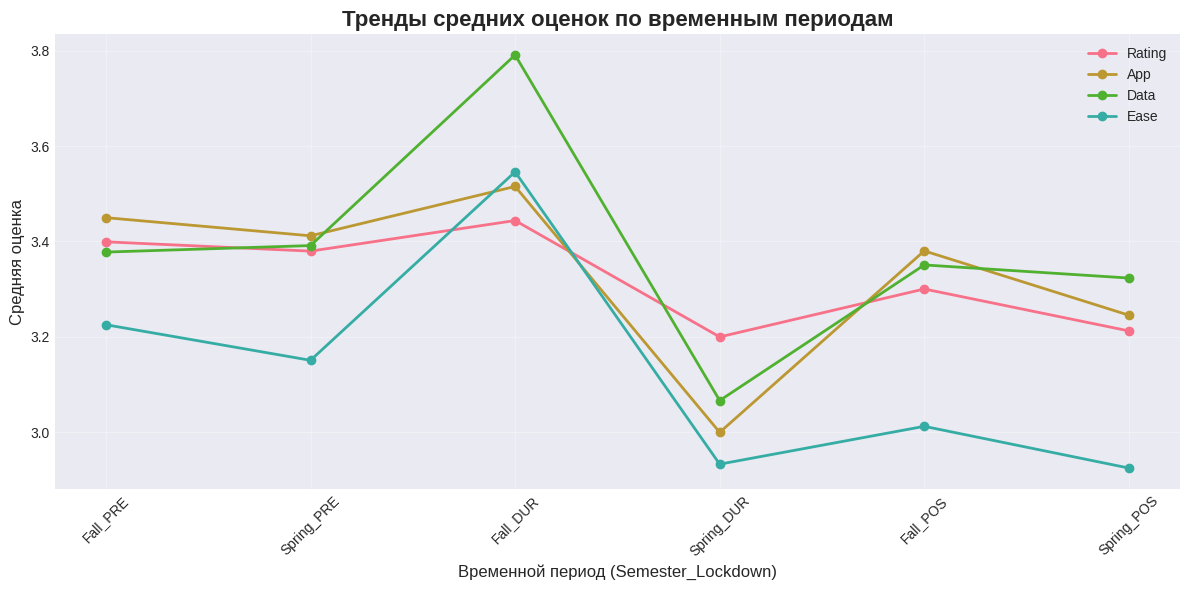


Статистическая значимость различий между временными периодами (ANOVA):
- Rating: F = 1.4073, p = 0.2181
- App: F = 2.1576, p = 0.0559
- Data: F = 4.8525, p = 0.0002
- Ease: F = 10.9306, p = 0.0000

------------------------------
АНАЛИЗ ГРУППОВЫХ РЕЙТИНГОВ
------------------------------
Сравнение средних индивидуальных и групповых оценок:


,Индивидуальные,Групповые
Rating,3.374,3.240
App,3.421,3.309
Data,3.390,3.313
Ease,3.177,3.236


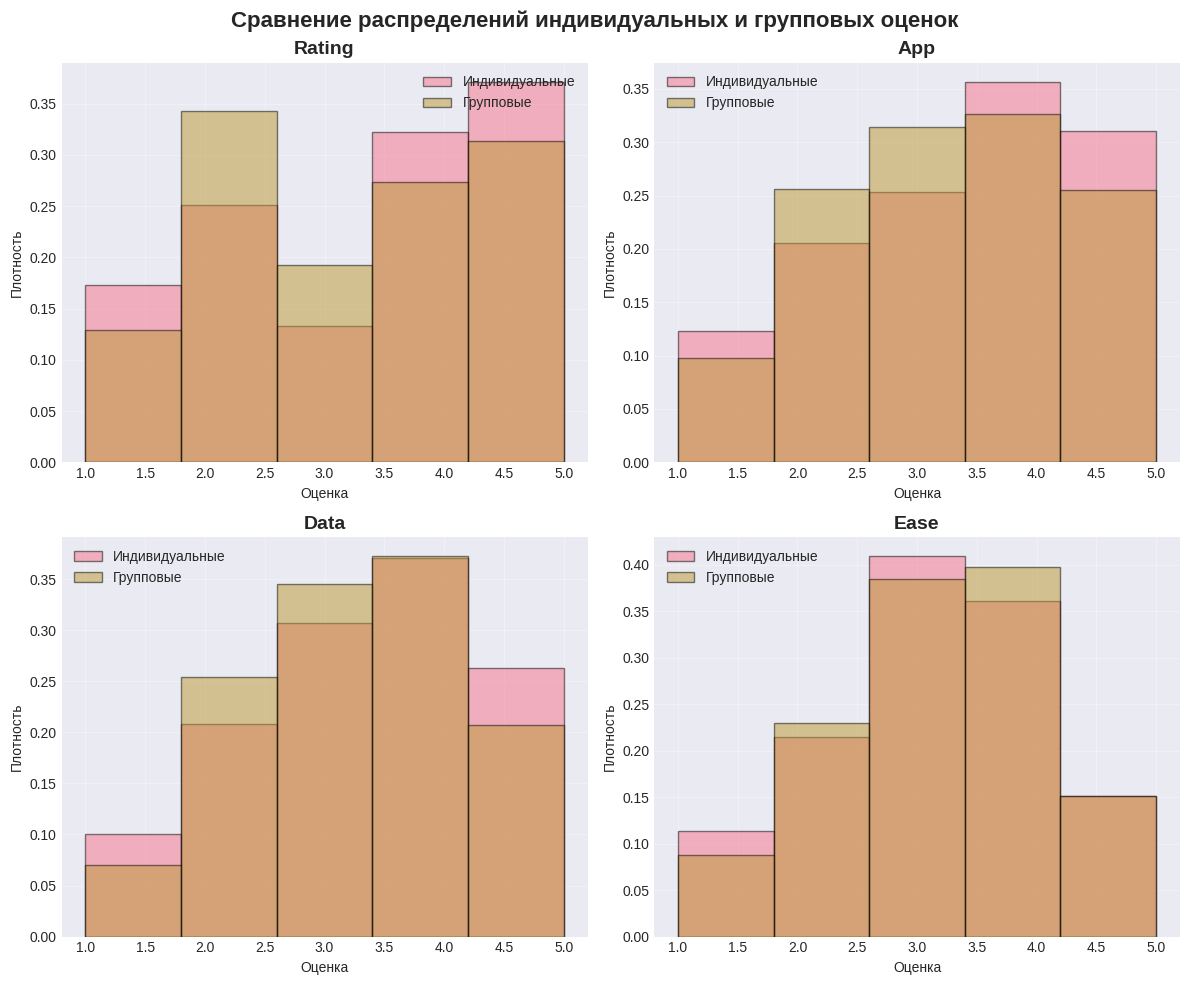


------------------------------
NLP АНАЛИЗ ОПИСАНИЙ ТЕМ (items.csv)
------------------------------
Статистика по признакам описаний:
Средняя длина описания (слов): 78.69
Доля описаний, содержащих 'data': 62.86%
Доля описаний, содержащих 'analy' (анализ): 15.71%
Доля описаний, содержащих 'system': 4.29%

Корреляция признаков описаний с оценками:


,desc_length,has_data,has_analy,has_system
Rating,0.107,0.063,-0.039,0.070
App,0.084,0.064,-0.047,0.058
Data,0.085,0.056,-0.039,0.058
Ease,0.063,0.070,-0.030,0.037



------------------------------
АНАЛИЗ ВЛИЯНИЯ ДЕМОГРАФИЧЕСКИХ ПЕРЕМЕННЫХ
------------------------------
Влияние пола (Gender) на оценки:


Rating                 App   Data   Ease
          mean    std count   mean   mean   mean
 Gender                                         
0        3.301  1.447  2150  3.381  3.373  3.151
1        3.425  1.425  3080  3.449  3.403  3.195


Влияние возрастной группы (Age) на оценки:


Rating                 App   Data   Ease
          mean    std count   mean   mean   mean
 Age                                            
 31-100  3.236  1.527   212  3.231  3.208  2.703
20-25    3.348  1.417  2193  3.403  3.366  3.143
26-30    3.424  1.444  2562  3.489  3.441  3.254
<20      3.279  1.120    43  3.163  3.070  3.000
>30      3.200  1.464   220  3.045  3.277  3.118


Влияние семейного положения (Married) на оценки:


Rating                 App   Data   Ease
          mean    std count   mean   mean   mean
Married                                         
0        3.407  1.425  4243  3.458  3.411  3.197
1        3.233  1.473   987  3.261  3.301  3.092

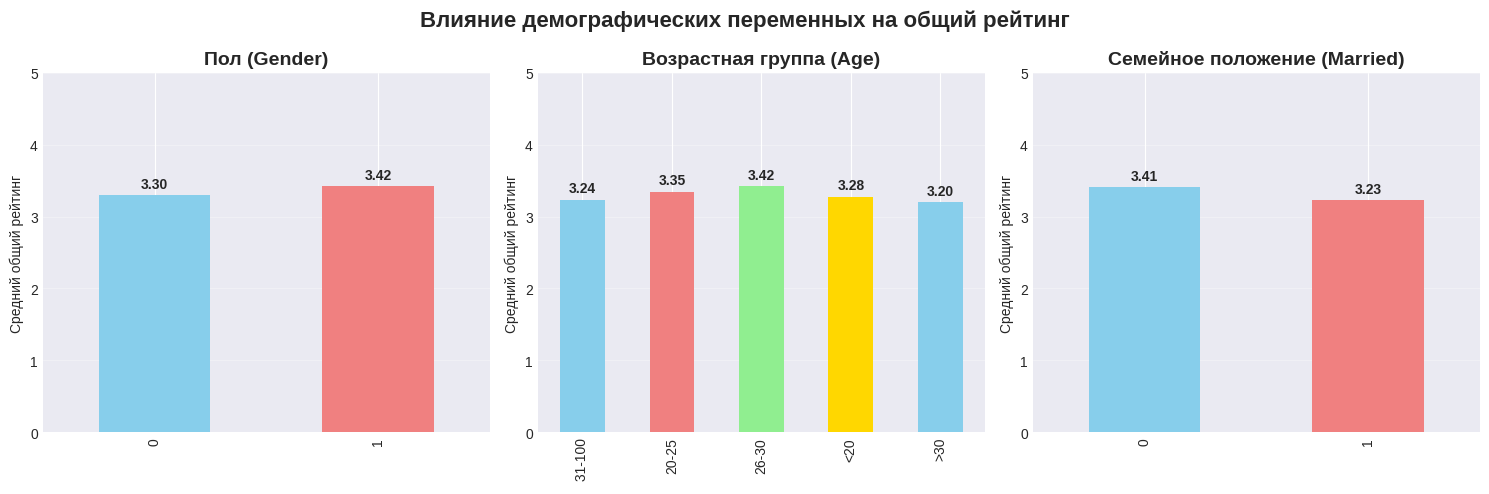


Статистическая значимость влияния демографии:
- Пол (Male vs Female): t = -3.0584, p = 0.0022
- Возрастные группы: F = 2.4175, p = 0.0644
- Семейное положение (Single vs Married): t = 3.4288, p = 0.0006


In [48]:
# ====================================================
# УГЛУБЛЁННЫЙ АНАЛИЗ
# ====================================================

print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ВРЕМЕННЫЕ ПАТТЕРНЫ, ГРУППЫ, NLP, ДЕМОГРАФИЯ")
print("="*50)

# 7.1 Временные паттерны
print("\n" + "-"*30)
print("АНАЛИЗ ВРЕМЕННЫХ ПАТТЕРНОВ")
print("-"*30)

# Создаем порядковую переменную времени: комбинация Semester и Lockdown
# Для простоты создадим 'time_period' как категориальную переменную в порядке времени
ratings['time_period'] = ratings['Semester'] + '_' + ratings['Lockdown']
# Определим порядок периодов: Fall_PRE, Spring_PRE, Fall_DUR, Spring_DUR, Fall_POS, Spring_POS
time_order = ['Fall_PRE', 'Spring_PRE', 'Fall_DUR', 'Spring_DUR', 'Fall_POS', 'Spring_POS']
ratings['time_period'] = pd.Categorical(ratings['time_period'], categories=time_order, ordered=True)

# Анализ средних оценок по временным периодам
time_trends = ratings.groupby('time_period')[['Rating', 'App', 'Data', 'Ease']].mean()

plt.figure(figsize=(12, 6))
for criterion in ['Rating', 'App', 'Data', 'Ease']:
    plt.plot(time_trends.index, time_trends[criterion], marker='o', label=criterion, linewidth=2)

plt.title('Тренды средних оценок по временным периодам', fontsize=16, fontweight='bold')
plt.xlabel('Временной период (Semester_Lockdown)', fontsize=12)
plt.ylabel('Средняя оценка', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Проверка статистической значимости различий между периодами (ANOVA)
print("\nСтатистическая значимость различий между временными периодами (ANOVA):")
for criterion in ['Rating', 'App', 'Data', 'Ease']:
    groups = [ratings[ratings['time_period'] == period][criterion] for period in time_order if period in ratings['time_period'].unique()]
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"- {criterion}: F = {f_stat:.4f}, p = {p_value:.4f}")

# 7.2 Анализ групповых рейтингов
print("\n" + "-"*30)
print("АНАЛИЗ ГРУППОВЫХ РЕЙТИНГОВ")
print("-"*30)

# Загружаем group_ratings и информацию о группах
group_ratings = pd.read_csv('/kaggle/input/itmrec/group_ratings.csv')
group_info = pd.read_csv('/kaggle/input/itmrec/group.csv')

group_ratings['Data'].fillna(group_ratings['Data'].median(), inplace=True)

# Объединяем групповые рейтинги с информацией о группах (если нужно)
# group_ratings_with_info = pd.merge(group_ratings, group_info, on='GroupID', how='left')

# Сравнение средних индивидуальных и групповых оценок
individual_means = ratings[['Rating', 'App', 'Data', 'Ease']].mean()
group_means = group_ratings[['Rating', 'App', 'Data', 'Ease']].mean()

comparison_df = pd.DataFrame({'Индивидуальные': individual_means, 'Групповые': group_means})
print("Сравнение средних индивидуальных и групповых оценок:")
display(comparison_df.round(3))

# Визуализация распределений
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
criteria = ['Rating', 'App', 'Data', 'Ease']
for idx, criterion in enumerate(criteria):
    ax = axes[idx//2, idx%2]
    ax.hist(ratings[criterion], bins=5, alpha=0.5, label='Индивидуальные', density=True, edgecolor='black')
    ax.hist(group_ratings[criterion], bins=5, alpha=0.5, label='Групповые', density=True, edgecolor='black')
    ax.set_title(criterion, fontsize=14, fontweight='bold')
    ax.set_xlabel('Оценка')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение распределений индивидуальных и групповых оценок', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 7.3 NLP анализ описаний тем (items.csv)
print("\n" + "-"*30)
print("NLP АНАЛИЗ ОПИСАНИЙ ТЕМ (items.csv)")
print("-"*30)

# Загружаем данные items
items = pd.read_csv('/kaggle/input/itmrec/items.csv')

# Базовая очистка текста
import re
def clean_text(text):
    if isinstance(text, str):
        # Удаляем специальные символы и цифры, приводим к нижнему регистру
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = text.lower()
        return text
    else:
        return ''

items['clean_description'] = items['Descriptions'].apply(clean_text)

# Извлечение простых признаков
items['desc_length'] = items['clean_description'].apply(lambda x: len(x.split()))
items['has_data'] = items['clean_description'].apply(lambda x: 1 if 'data' in x else 0)
items['has_analy'] = items['clean_description'].apply(lambda x: 1 if 'analy' in x else 0)
items['has_system'] = items['clean_description'].apply(lambda x: 1 if 'system' in x else 0)

print("Статистика по признакам описаний:")
print(f"Средняя длина описания (слов): {items['desc_length'].mean():.2f}")
print(f"Доля описаний, содержащих 'data': {items['has_data'].mean():.2%}")
print(f"Доля описаний, содержащих 'analy' (анализ): {items['has_analy'].mean():.2%}")
print(f"Доля описаний, содержащих 'system': {items['has_system'].mean():.2%}")

# Объединяем признаки описаний с рейтингами для анализа влияния
item_features = items[['Item', 'desc_length', 'has_data', 'has_analy', 'has_system']]
ratings_with_items = pd.merge(ratings, item_features, on='Item', how='left')

# Проверяем корреляцию признаков описаний с оценками
nlp_corr = ratings_with_items[['Rating', 'App', 'Data', 'Ease', 'desc_length', 'has_data', 'has_analy', 'has_system']].corr()
nlp_corr_target = nlp_corr.loc[['Rating', 'App', 'Data', 'Ease'], ['desc_length', 'has_data', 'has_analy', 'has_system']]

print("\nКорреляция признаков описаний с оценками:")
display(nlp_corr_target.round(3))

# 7.4 Влияние демографии (users.csv)
print("\n" + "-"*30)
print("АНАЛИЗ ВЛИЯНИЯ ДЕМОГРАФИЧЕСКИХ ПЕРЕМЕННЫХ")
print("-"*30)

# Загружаем users и объединяем с рейтингами
users = pd.read_csv('/kaggle/input/itmrec/users.csv')
ratings_with_users = pd.merge(ratings, users, on='UserID', how='left')

# Анализ влияния пола (Gender)
gender_analysis = ratings_with_users.groupby(' Gender').agg({
    'Rating': ['mean', 'std', 'count'],
    'App': 'mean',
    'Data': 'mean',
    'Ease': 'mean'
}).round(3)

print("Влияние пола (Gender) на оценки:")
display(gender_analysis)

# Анализ влияния возраста (Age)
age_analysis = ratings_with_users.groupby(' Age').agg({
    'Rating': ['mean', 'std', 'count'],
    'App': 'mean',
    'Data': 'mean',
    'Ease': 'mean'
}).round(3)

print("\nВлияние возрастной группы (Age) на оценки:")
display(age_analysis)

# Анализ влияния семейного положения (Married)
married_analysis = ratings_with_users.groupby('Married').agg({
    'Rating': ['mean', 'std', 'count'],
    'App': 'mean',
    'Data': 'mean',
    'Ease': 'mean'
}).round(3)

print("\nВлияние семейного положения (Married) на оценки:")
display(married_analysis)

# Визуализация влияния демографии
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
demographic_vars = [' Gender', ' Age', 'Married']
titles = ['Пол (Gender)', 'Возрастная группа (Age)', 'Семейное положение (Married)']

for idx, (var, title) in enumerate(zip(demographic_vars, titles)):
    ax = axes[idx]
    group_means = ratings_with_users.groupby(var)['Rating'].mean()
    group_means.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'][:len(group_means)])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Средний общий рейтинг')
    ax.set_ylim(0, 5)
    ax.grid(True, alpha=0.3, axis='y')
    # Добавляем значения на столбцы
    for i, v in enumerate(group_means):
        ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Влияние демографических переменных на общий рейтинг', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Проверка статистической значимости различий (ANOVA для возраста, t-test для пола и семейного положения)
print("\nСтатистическая значимость влияния демографии:")
# Пол: t-test между Male и Female (если есть оба)
if 0 in ratings_with_users[' Gender'].values and 1 in ratings_with_users[' Gender'].values:
    male_ratings = ratings_with_users[ratings_with_users[' Gender'] == 0]['Rating']
    female_ratings = ratings_with_users[ratings_with_users[' Gender'] == 1]['Rating']
    t_stat, p_value = stats.ttest_ind(male_ratings, female_ratings)
    print(f"- Пол (Male vs Female): t = {t_stat:.4f}, p = {p_value:.4f}")

# Возрастные группы: ANOVA
age_labels = ['<20', '20-25', '26-30', '>30', '31-100']
age_groups = [ratings_with_users[ratings_with_users[' Age'] == group]['Rating'] for group in age_labels if group in ratings_with_users[' Age'].unique()]
if len(age_groups) > 1:
    f_stat, p_value = stats.f_oneway(*age_groups)
    print(f"- Возрастные группы: F = {f_stat:.4f}, p = {p_value:.4f}")

# Семейное положение: t-test между Single и Married
if 0 in ratings_with_users['Married'].values and 1 in ratings_with_users['Married'].values:
    single_ratings = ratings_with_users[ratings_with_users['Married'] == 0]['Rating']
    married_ratings = ratings_with_users[ratings_with_users['Married'] == 1]['Rating']
    t_stat, p_value = stats.ttest_ind(single_ratings, married_ratings)
    print(f"- Семейное положение (Single vs Married): t = {t_stat:.4f}, p = {p_value:.4f}")

**Ключевые выводы:**
- Статистическая значимость есть только для Data и Ease (p < 0.001)
- Rating и App не показывают значимых изменений во времени (p > 0.05)
- Ключевая находка: В период COVID (DUR/POS) студенты сильнее ценили "простоту" (Ease) тем
- Также до этого можно было наблюдать сильную корреляцию с другими признаками (класс)

**Импликация для RL-системы:**

State должен включать временные контекстные признаки: Semester (Fall/Spring) и Lockdown (PRE/DUR/POS) как one-hot энкодинг. Это позволит агенту адаптировать стратегию рекомендаций в зависимости от временного контекста. Также при обучении в симуляции усиливать награду за Ease в контексте DUR/POS

------------------------------
**Групповые рейтинги (Контр-интуитивный результат):**
- Групповые оценки ниже индивидуальных (противоположно ожидаемому)
- Наибольшая разница по Rating (-0.134) и App (-0.112)
- Ease единственный критерий, где группы выше (+0.059)

**Импликация для RL:**
- Не использовать групповые оценки как приор для индивидуальных рекомендаций
- Разработать отдельную стратегию для групповых рекомендаций с акцентом на Ease
- Механизм компромисса: В групповом контексте система должна находить баланс между сложностью и другими критериями

------------------------------
**NLP анализ (Слабые корреляции):**
- Корреляции описаний с оценками очень слабые (0.03-0.11)
- Длина описания положительно коррелирует с рейтингом (+0.11)
- Термины "data", "analy", "system" практически не влияют на оценки

**Импликация для RL:**
- Не тратить вычислительные ресурсы на сложные NLP-эмбеддинги
- Использовать простые признаки (длина описания, наличие ключевых слов)
- Приоритизировать collaborative filtering признаки над content-based

------------------------------
**Демография (Сильное влияние):**
- Пол (Gender): Мужчины (1) ставят выше по всем критериям
- Семейное положение: Неженатые (0) оценивают выше (разница 0.174 для Rating, p=0.0006)
- Возраст: Пик оценок в группе 26-30 лет, снижение после 30

**Импликация для RL:**
- Обязательно включать демографические признаки в state representation
- Разные стратегии exploration-exploitation для разных демографических групп
- "Холодный старт": Использовать демографию как сильный приор для новых пользователей

# Реализация DeepFM+SVD++ и DQN

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import warnings
import types
warnings.filterwarnings('ignore')

# Загрузка и предобработка данных
print("="*50)
print("1. ПРЕДОБУЧЕНИЕ DeepFM-SVD++")
print("="*50)

class ITMDataset(Dataset):
    """Датасет для обучения DeepFM-SVD++"""
    def __init__(self, ratings_df, users_df, items_df):
        # Кодирование категориальных признаков
        self.user_encoder = LabelEncoder()
        self.item_encoder = LabelEncoder()
        self.class_encoder = LabelEncoder()
        self.semester_encoder = LabelEncoder()
        self.lockdown_encoder = LabelEncoder()
        
        # Подготовка данных
        self.ratings = ratings_df.copy()
        self.users = users_df.copy()
        self.items = items_df.copy()
        
        # Кодирование
        self.ratings['UserID_encoded'] = self.user_encoder.fit_transform(self.ratings['UserID'])
        self.ratings['ItemID_encoded'] = self.item_encoder.fit_transform(self.ratings['Item'])
        self.ratings['Class_encoded'] = self.class_encoder.fit_transform(self.ratings['Class'])
        self.ratings['Semester_encoded'] = self.semester_encoder.fit_transform(self.ratings['Semester'])
        self.ratings['Lockdown_encoded'] = self.lockdown_encoder.fit_transform(self.ratings['Lockdown'])
        
        # Нормализация рейтингов
        self.rating_scaler = MinMaxScaler()
        self.ratings['Rating_norm'] = self.rating_scaler.fit_transform(
            self.ratings[['Rating']]
        )
        
        # Размерности
        self.n_users = len(self.user_encoder.classes_)
        self.n_items = len(self.item_encoder.classes_)
        self.n_classes = len(self.class_encoder.classes_)
        self.n_semesters = len(self.semester_encoder.classes_)
        self.n_lockdowns = len(self.lockdown_encoder.classes_)
        
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        row = self.ratings.iloc[idx]
        
        # Мультикритериальные таргеты
        targets = torch.FloatTensor([
            row['Rating_norm'],
            row['App'] / 5.0,  # Нормализация к [0, 1]
            row['Data'] / 5.0,
            row['Ease'] / 5.0
        ])
        
        # Признаки
        features = {
            'user_id': torch.LongTensor([row['UserID_encoded']]),
            'item_id': torch.LongTensor([row['ItemID_encoded']]),
            'class': torch.LongTensor([row['Class_encoded']]),
            'semester': torch.LongTensor([row['Semester_encoded']]),
            'lockdown': torch.LongTensor([row['Lockdown_encoded']]),
        }
        
        return features, targets

# DeepFM-SVD++ Модель
class DeepFMSVDPlusPlus(nn.Module):
    def __init__(self, n_users, n_items, n_classes, n_semesters, n_lockdowns, device,
                 embedding_dim=32, hidden_dims=[64, 32], dropout_rate=0.2):
        super(DeepFMSVDPlusPlus, self).__init__()
        
        # Эмбеддинги для FM части
        self.user_emb_fm = nn.Embedding(n_users, embedding_dim)
        self.item_emb_fm = nn.Embedding(n_items, embedding_dim)
        self.class_emb_fm = nn.Embedding(n_classes, embedding_dim // 2)
        self.semester_emb_fm = nn.Embedding(n_semesters, embedding_dim // 4)
        self.lockdown_emb_fm = nn.Embedding(n_lockdowns, embedding_dim // 4)
        
        # Эмбеддинги для SVD++ (implicit feedback)
        self.user_emb_svd = nn.Embedding(n_users, embedding_dim)
        self.item_emb_svd = nn.Embedding(n_items, embedding_dim)
        
        # Linear bias terms
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        
        # Deep часть
        # Размеры эмбеддингов:
        # user_emb_fm: embedding_dim
        # item_emb_fm: embedding_dim
        # class_emb: embedding_dim // 2
        # semester_emb: embedding_dim // 4
        # lockdown_emb: embedding_dim // 4
        # user_emb_svd: embedding_dim
        # item_emb_svd: embedding_dim
        # ИТОГО: 4*embedding_dim + embedding_dim//2 + 2*(embedding_dim//4) = 4*32 + 16 + 16 = 160
        total_embed_dim = embedding_dim * 4 + (embedding_dim // 2) + (embedding_dim // 4) * 2
        
        deep_layers = []
        deep_input_dim = total_embed_dim
        
        for hidden_dim in hidden_dims:
            deep_layers.append(nn.Linear(deep_input_dim, hidden_dim))
            deep_layers.append(nn.BatchNorm1d(hidden_dim))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(dropout_rate))
            deep_input_dim = hidden_dim
        
        self.deep_network = nn.Sequential(*deep_layers)
        
        # Выходные слои для каждого критерия
        # Размер hidden_dims[-1] + 1 (fm_second_order) + 1 (linear_terms) = hidden_dims[-1] + 2
        self.rating_output = nn.Linear(hidden_dims[-1] + 2, 1)
        self.app_output = nn.Linear(hidden_dims[-1] + 2, 1)
        self.data_output = nn.Linear(hidden_dims[-1] + 2, 1)
        self.ease_output = nn.Linear(hidden_dims[-1] + 2, 1)

        self.device = device
        
        # Инициализация
        self._init_weights()
    
    def _init_weights(self):
        for emb_layer in [self.user_emb_fm, self.item_emb_fm, self.user_emb_svd, self.item_emb_svd]:
            nn.init.xavier_uniform_(emb_layer.weight)
        
        for layer in self.deep_network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    
    def forward(self, user_ids, item_ids, class_ids, semester_ids, lockdown_ids, 
                user_history=None):
        # FM часть: линейные и попарные взаимодействия
        user_emb_fm = self.user_emb_fm(user_ids)
        item_emb_fm = self.item_emb_fm(item_ids)
        class_emb = self.class_emb_fm(class_ids)
        semester_emb = self.semester_emb_fm(semester_ids)
        lockdown_emb = self.lockdown_emb_fm(lockdown_ids)
        
        # Линейные термины
        linear_terms = self.user_bias(user_ids).squeeze() + \
                      self.item_bias(item_ids).squeeze() + \
                      self.global_bias
        
        # Попарные взаимодействия FM
        # Формула: 0.5 * (sum_i sum_j <v_i, v_j> x_i x_j) = 
        # 0.5 * ((sum_i v_i x_i)^2 - sum_i (v_i^2 x_i^2))
        
        # Взаимодействия между user и item embeddings
        interaction_term = torch.sum(user_emb_fm * item_emb_fm, dim=1)  # [batch_size]
        
        # Квадрат суммы взаимодействий
        square_of_sum = torch.pow(interaction_term, 2)  # [batch_size]
        
        # Сумма квадратов
        sum_of_squares = torch.sum(torch.pow(user_emb_fm, 2) * torch.pow(item_emb_fm, 2), dim=1)  # [batch_size]
        
        # FM второго порядка
        fm_second_order = 0.5 * (square_of_sum - sum_of_squares)  # [batch_size]
        
        # SVD++ часть: implicit feedback
        if user_history is not None and len(user_history) > 0:
            # Усреднение эмбеддингов просмотренных items
            history_embs = self.item_emb_svd(user_history)
            history_mean = torch.mean(history_embs, dim=1)
            user_emb_svd = self.user_emb_svd(user_ids) + history_mean
        else:
            user_emb_svd = self.user_emb_svd(user_ids)
        
        item_emb_svd = self.item_emb_svd(item_ids)
        
        # Объединение всех эмбеддингов для deep части
        deep_input = torch.cat([
            user_emb_fm, item_emb_fm, 
            class_emb, semester_emb, lockdown_emb,
            user_emb_svd, item_emb_svd
        ], dim=1)
        
        # Deep часть
        deep_output = self.deep_network(deep_input)
        
        # Объединение FM и Deep для финального предсказания
        combined_features = torch.cat([
            deep_output, 
            fm_second_order.unsqueeze(1), 
            linear_terms.unsqueeze(1)
        ], dim=1)
        
        # Предсказания для каждого критерия
        rating_pred = torch.sigmoid(self.rating_output(combined_features))
        app_pred = torch.sigmoid(self.app_output(combined_features))
        data_pred = torch.sigmoid(self.data_output(combined_features))
        ease_pred = torch.sigmoid(self.ease_output(combined_features))
        
        return {
            'rating': rating_pred.squeeze(),
            'app': app_pred.squeeze(),
            'data': data_pred.squeeze(),
            'ease': ease_pred.squeeze()
        }
    
    def get_embeddings(self, user_ids, item_ids):
        """Получение эмбеддингов для RL агента"""
        with torch.no_grad():
            user_emb = self.user_emb_fm(user_ids)
            item_emb = self.item_emb_fm(item_ids)
            
            # Конкатенация с SVD++ эмбеддингами
            user_emb_svd = self.user_emb_svd(user_ids)
            item_emb_svd = self.item_emb_svd(item_ids)
            
            user_final = torch.cat([user_emb, user_emb_svd], dim=1)
            item_final = torch.cat([item_emb, item_emb_svd], dim=1)
            
            return user_final, item_final

# Обучение модели
def train_deepfm_svdplusplus():
    print("Загрузка данных...")
    ratings = pd.read_csv('/kaggle/input/itmrec/ratings.csv')
    users = pd.read_csv('/kaggle/input/itmrec/users.csv')
    items = pd.read_csv('/kaggle/input/itmrec/items.csv')
    
    # Заполнение пропусков
    ratings['Data'].fillna(ratings['Data'].median(), inplace=True)
    
    # Создание датасета
    dataset = ITMDataset(ratings, users, items)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Создание модели
    model = DeepFMSVDPlusPlus(
        n_users=dataset.n_users,
        n_items=dataset.n_items,
        n_classes=dataset.n_classes,
        n_semesters=dataset.n_semesters,
        n_lockdowns=dataset.n_lockdowns,
        embedding_dim=32,
        hidden_dims=[64, 32],
        device=device
    )
    
    # Оптимизатор и функция потерь
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    # Обучение
    model.to(device)
    
    print(f"Обучение на {device}...")
    n_epochs = 50
    best_val_loss = float('inf')
    
    for epoch in range(n_epochs):
        # Train phase
        model.train()
        train_loss = 0.0
        for batch_idx, (features, targets) in enumerate(train_loader):
            # Перемещение на device
            for key in features:
                features[key] = features[key].to(device)
            targets = targets.to(device)
            
            # Forward pass
            outputs = model(
                features['user_id'].squeeze(),
                features['item_id'].squeeze(),
                features['class'].squeeze(),
                features['semester'].squeeze(),
                features['lockdown'].squeeze()
            )
            
            # Расчет потерь для каждого критерия
            loss = (criterion(outputs['rating'], targets[:, 0]) +
                   criterion(outputs['app'], targets[:, 1]) +
                   criterion(outputs['data'], targets[:, 2]) +
                   criterion(outputs['ease'], targets[:, 3])) / 4.0
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for features, targets in val_loader:
                for key in features:
                    features[key] = features[key].to(device)
                targets = targets.to(device)
                
                outputs = model(
                    features['user_id'].squeeze(),
                    features['item_id'].squeeze(),
                    features['class'].squeeze(),
                    features['semester'].squeeze(),
                    features['lockdown'].squeeze()
                )
                
                loss = (criterion(outputs['rating'], targets[:, 0]) +
                       criterion(outputs['app'], targets[:, 1]) +
                       criterion(outputs['data'], targets[:, 2]) +
                       criterion(outputs['ease'], targets[:, 3])) / 4.0
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Epoch {epoch+1}/{n_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        
        # Сохранение лучшей модели
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'user_encoder': dataset.user_encoder,
                'item_encoder': dataset.item_encoder,
                'class_encoder': dataset.class_encoder,
                'semester_encoder': dataset.semester_encoder,
                'lockdown_encoder': dataset.lockdown_encoder,
                'rating_scaler': dataset.rating_scaler
            }, '/kaggle/working/deepfm_svdplusplus_best.pth')
            print("Сохранена лучшая модель")
    
    print("\n" + "="*50)
    print("Предобучение DeepFM-SVD++ завершено!")
    print(f"Лучшая validation loss: {best_val_loss:.4f}")
    
    return model, dataset

# Запуск обучения
model, dataset = train_deepfm_svdplusplus()

1. ПРЕДОБУЧЕНИЕ DeepFM-SVD++
Загрузка данных...
Обучение на cuda...
Epoch 1/50
  Train Loss: 0.0963, Val Loss: 0.0837
Сохранена лучшая модель
Epoch 2/50
  Train Loss: 0.0794, Val Loss: 0.0763
Сохранена лучшая модель
Epoch 3/50
  Train Loss: 0.0726, Val Loss: 0.0713
Сохранена лучшая модель
Epoch 4/50
  Train Loss: 0.0672, Val Loss: 0.0685
Сохранена лучшая модель
Epoch 5/50
  Train Loss: 0.0630, Val Loss: 0.0664
Сохранена лучшая модель
Epoch 6/50
  Train Loss: 0.0597, Val Loss: 0.0662
Сохранена лучшая модель
Epoch 7/50
  Train Loss: 0.0572, Val Loss: 0.0668
Epoch 8/50
  Train Loss: 0.0554, Val Loss: 0.0669
Epoch 9/50
  Train Loss: 0.0550, Val Loss: 0.0664
Epoch 10/50
  Train Loss: 0.0535, Val Loss: 0.0662
Сохранена лучшая модель
Epoch 11/50
  Train Loss: 0.0524, Val Loss: 0.0665
Epoch 12/50
  Train Loss: 0.0511, Val Loss: 0.0676
Epoch 13/50
  Train Loss: 0.0506, Val Loss: 0.0671
Epoch 14/50
  Train Loss: 0.0490, Val Loss: 0.0671
Epoch 15/50
  Train Loss: 0.0483, Val Loss: 0.0672
Epoch 16

In [2]:
print("\n" + "="*50)
print("2. КОДИРОВАНИЕ СИМУЛЯТОРА ОБРАЗОВАТЕЛЬНОЙ СРЕДЫ")
print("="*50)

class EducationalEnvironment:
    def __init__(self, ratings_df, users_df, items_df, deepfm_model, dataset):
        # Используем dataset.ratings, который содержит закодированные колонки
        self.ratings = dataset.ratings.copy()
        self.users = users_df.copy()
        self.items = items_df.copy()
        self.model = deepfm_model
        self.dataset = dataset
        
        # Определение устройства
        self.device = next(self.model.parameters()).device
        
        # Кэширование
        self.user_history_cache = {}
        self.item_features_cache = {}
        self.user_embeddings_cache = {}
        
        # Параметры среды
        self.max_trajectory_length = 10
        self.max_recommendations = 5
        self.novelty_weight = 0.05
        
        # Инициализация кэшей
        self._initialize_caches()
    
    def _initialize_caches(self):
        """Инициализация кэшей для ускорения работы"""
        print("Инициализация кэшей...")
        
        # Кэш эмбеддингов предметов
        all_item_ids = torch.arange(self.dataset.n_items).long().to(self.device)
        with torch.no_grad():
            item_embeddings = self.model.item_emb_fm(all_item_ids)
            self.item_embeddings_cache = item_embeddings.cpu().numpy()
        
        # Кэш истории пользователей
        for user_id in self.ratings['UserID_encoded'].unique():
            user_history = self.ratings[
                self.ratings['UserID_encoded'] == user_id
            ]['ItemID_encoded'].tolist()
            self.user_history_cache[user_id] = user_history[:10]  # Последние 10
        
        print(f"Кэши инициализированы: {len(self.user_history_cache)} пользователей, {len(self.item_embeddings_cache)} предметов")
    
    def reset(self, user_id=None, context=None):
        """Сброс среды для нового эпизода"""
        if user_id is None:
            # Случайный выбор пользователя
            self.current_user = np.random.choice(self.ratings['UserID_encoded'].unique())
        else:
            self.current_user = user_id
        
        # Установка контекста
        if context is None:
            # Случайный контекст на основе истории пользователя
            user_data = self.ratings[self.ratings['UserID_encoded'] == self.current_user]
            if len(user_data) > 0:
                sample = user_data.iloc[0]
                self.current_context = {
                    'class': int(sample['Class_encoded']),
                    'semester': int(sample['Semester_encoded']),
                    'lockdown': int(sample['Lockdown_encoded'])
                }
            else:
                # Контекст по умолчанию
                self.current_context = {
                    'class': 0,  # DA
                    'semester': 0,  # Fall
                    'lockdown': 0  # PRE
                }
        else:
            self.current_context = context
        
        # Сброс состояния эпизода
        self.trajectory = []
        self.recommended_items = set()
        self.step_count = 0
        self.cumulative_reward = 0.0
        
        # Получение начального состояния
        initial_state = self._get_state()
        
        print(f"Эпизод начат: User {self.current_user}, Context {self.current_context}")
        
        return initial_state
    
    def _get_state(self):
        """Формирование вектора состояния s_t"""
        state_components = []
        
        # 1. User Embedding (32-dim)
        user_emb = self._get_user_embedding(self.current_user)
        state_components.append(user_emb)
        
        # 2. Контекстный вектор (10-dim)
        context_vector = self._encode_context(self.current_context)
        state_components.append(context_vector)
        
        # 3. Демографический вектор (6-dim)
        demo_vector = self._get_demographic_vector(self.current_user)
        state_components.append(demo_vector)
        
        # 4. История взаимодействий (15-dim)
        history_vector = self._encode_history(self.trajectory)
        state_components.append(history_vector)
        
        # 5. Временные метки (2-dim)
        time_vector = np.array([
            self.step_count / self.max_trajectory_length,  # Прогресс эпизода
            len(self.trajectory) / 10.0  # Длина истории
        ])
        state_components.append(time_vector)
        
        # Объединение всех компонентов
        state = np.concatenate(state_components, axis=0)
        
        # Проверка размерности
        expected_dim = 32 + 10 + 6 + 15 + 2  # 65
        assert len(state) == expected_dim, f"State dimension mismatch: {len(state)} != {expected_dim}"
        
        return state
    
    def _get_user_embedding(self, user_id):
        """Получение эмбеддинга пользователя"""
        if user_id in self.user_embeddings_cache:
            return self.user_embeddings_cache[user_id]
        
        # Вычисление эмбеддинга через модель
        user_tensor = torch.LongTensor([user_id]).to(self.device)
        with torch.no_grad():
            user_emb = self.model.user_emb_fm(user_tensor).cpu().numpy().flatten()
        
        self.user_embeddings_cache[user_id] = user_emb
        return user_emb
    
    def _encode_context(self, context):
        """Кодирование контекстных переменных"""
        # One-hot кодирование
        class_onehot = np.zeros(3)  # DA, DB, DM
        class_onehot[context['class']] = 1
        
        semester_onehot = np.zeros(2)  # Fall, Spring
        semester_onehot[context['semester']] = 1
        
        lockdown_onehot = np.zeros(3)  # PRE, DUR, POS
        lockdown_onehot[context['lockdown']] = 1
        
        # Время в семестре (нормализованное)
        time_in_semester = np.random.random()  # Для симуляции
        
        # Успешность предыдущих рекомендаций
        if len(self.trajectory) > 0:
            success_rate = np.mean([1 if r['reward'] > 0.5 else 0 for r in self.trajectory])
        else:
            success_rate = 0.5
        
        context_vector = np.concatenate([
            class_onehot,
            semester_onehot,
            lockdown_onehot,
            [time_in_semester],
            [success_rate]
        ])
        
        return context_vector
    
    def _get_demographic_vector(self, user_id):
        """Получение демографического вектора"""
        # Поиск реального UserID
        original_user_id = self.dataset.user_encoder.inverse_transform([user_id])[0]
        user_data = self.users[self.users['UserID'] == original_user_id]
        
        if len(user_data) == 0:
            # Данные по умолчанию
            return np.array([0, 0, 0, 0, 0, 1])  # Female, 26-30, не женат
        
        row = user_data.iloc[0]
        
        # Gender (0=Female, 1=Male)
        gender = 1 if row[' Gender'] == 1 else 0
        
        # Age group one-hot
        age = row[' Age']
        age_onehot = np.zeros(4)
        if age == '<20':
            age_onehot[0] = 1
        elif age == '20-25':
            age_onehot[1] = 1
        elif age == '26-30':
            age_onehot[2] = 1
        else:
            age_onehot[3] = 1
        
        # Married (0=Single, 1=Married)
        married = 1 if row['Married'] == 1 else 0
        
        return np.concatenate([[gender], age_onehot, [married]])
    
    def _encode_history(self, trajectory):
        """Кодирование истории взаимодействий"""
        if len(trajectory) == 0:
            return np.zeros(15)  # 3 interactions × 5 features
        
        # Берем последние 3 взаимодействия
        recent_history = trajectory[-3:]
        
        history_vectors = []
        for interaction in recent_history:
            # Эмбеддинг предмета (первые 4 измерения)
            item_emb = self.item_embeddings_cache[interaction['item_id']]
            item_emb_compressed = item_emb[:4]  # Сжатие до 4 измерений
            
            # Нормализованный рейтинг
            rating_norm = interaction['rating'] / 5.0
            
            # Время с момента взаимодействия (нормализованное)
            time_since = interaction.get('time_since', 0.1)
            
            # Дополнительные признаки
            additional_features = np.array([
                interaction.get('app', 0.5) / 5.0,
                interaction.get('data', 0.5) / 5.0,
                interaction.get('ease', 0.5) / 5.0
            ])
            
            interaction_vector = np.concatenate([
                item_emb_compressed,
                [rating_norm, time_since],
                additional_features
            ])
            history_vectors.append(interaction_vector)
        
        # Дополнение нулями, если истории недостаточно
        while len(history_vectors) < 3:
            history_vectors.append(np.zeros(5))
        
        # Объединение
        full_history = np.concatenate(history_vectors)
        
        # Проверка размерности
        if len(full_history) != 15:  # 3 × 5
            # Обрезка или дополнение
            full_history = np.pad(full_history, (0, max(0, 15 - len(full_history))))[:15]
        
        return full_history
    
    def step(self, action):
        """
        Выполнение шага в среде
    
        Args:
            action: ID предмета для рекомендации (0-69)
        
        Returns:
            next_state, reward, done, info
        """
        self.step_count += 1
    
        # Проверка валидности действия
        if action < 0 or action >= self.dataset.n_items:
            raise ValueError(f"Invalid action: {action}")
    
        # Добавление в рекомендованные
        self.recommended_items.add(action)
    
        # Имитация фидбека от пользователя
        feedback = self._simulate_feedback(action)
    
        # Расчет вознаграждения
        reward = self._calculate_reward(feedback, action)
        self.cumulative_reward += reward
    
        # Обновление траектории
        interaction_record = {
            'item_id': action,
            'rating': feedback['rating'],
            'app': feedback['app'],
            'data': feedback['data'],
            'ease': feedback['ease'],
            'reward': reward,
            'time_since': 1.0 / (self.step_count + 1)  # Уменьшение со временем
        }
        self.trajectory.append(interaction_record)
    
        # Проверка завершения эпизода
        done = self._check_termination()
    
        # Получение следующего состояния
        if not done:
            next_state = self._get_state()
        else:
            # Вместо None возвращаем нулевой вектор состояния
            next_state = np.zeros(65)  # Размерность состояния = 65
    
        # Информация для отладки
        info = {
            'user_id': self.current_user,
            'item_id': action,
            'actual_ratings': feedback,
            'step': self.step_count,
            'cumulative_reward': self.cumulative_reward,
            'trajectory_length': len(self.trajectory)
        }
    
        return next_state, reward, done, info
    
    def _simulate_feedback(self, item_id):
        """Имитация реакции пользователя"""
        # Поиск реальной оценки, если есть
        user_ratings = self.ratings[
            (self.ratings['UserID_encoded'] == self.current_user) & 
            (self.ratings['ItemID_encoded'] == item_id)
        ]
        
        if not user_ratings.empty:
            # Используем медианную оценку
            feedback = {
                'rating': float(user_ratings['Rating'].median()),
                'app': float(user_ratings['App'].median()),
                'data': float(user_ratings['Data'].median()),
                'ease': float(user_ratings['Ease'].median())
            }
        else:
            # Предсказание через модель
            with torch.no_grad():
                user_tensor = torch.LongTensor([self.current_user]).to(self.device)
                item_tensor = torch.LongTensor([item_id]).to(self.device)
                class_tensor = torch.LongTensor([self.current_context['class']]).to(self.device)
                semester_tensor = torch.LongTensor([self.current_context['semester']]).to(self.device)
                lockdown_tensor = torch.LongTensor([self.current_context['lockdown']]).to(self.device)
                
                # Получение истории пользователя
                user_history = self.user_history_cache.get(self.current_user, [])
                if user_history:
                    history_tensor = torch.LongTensor(user_history[:5]).unsqueeze(0).to(self.device)
                else:
                    history_tensor = None
                
                # Предсказание
                predictions = self.model(
                    user_tensor, item_tensor, class_tensor, 
                    semester_tensor, lockdown_tensor, history_tensor
                )
                
                # Перенос на CPU для получения значений
                feedback = {
                    'rating': predictions['rating'].cpu().item() * 5.0,
                    'app': predictions['app'].cpu().item() * 5.0,
                    'data': predictions['data'].cpu().item() * 5.0,
                    'ease': predictions['ease'].cpu().item() * 5.0
                }
        
        # Добавление шума для реалистичности - для тестирование не нужно!
        #noise_scale = 0.1
        #for key in feedback:
        #    feedback[key] += np.random.normal(0, noise_scale)
        #    feedback[key] = np.clip(feedback[key], 1.0, 5.0)
        
        return feedback
    
    def _calculate_reward(self, feedback, action):
        """Расчет вознаграждения по многокритериальной формуле"""
        # Базовые веса из EDA
        weights = {'w1': 0.50, 'w2': 0.30, 'w3': 0.15, 'w4': 0.05}
        
        # Корректировка весов по контексту
        if self.current_context['lockdown'] in [1, 2]:  # DUR или POS
            weights['w3'] = 0.25  # Усиление важности Ease
            weights['w1'] = 0.45
        
        if self.current_context['class'] == 1:  # DB
            weights['w2'] = 0.35  # Усиление важности Data
        
        # Демографический множитель
        demo_vector = self._get_demographic_vector(self.current_user)
        married = demo_vector[-1]
        age_group = np.argmax(demo_vector[1:5])
        
        demo_multiplier = 1.0
        if married == 1:
            demo_multiplier *= 0.9  # Женатые более критичны
        
        if age_group in [0, 1]:  # <20 или 20-25
            demo_multiplier *= 1.1  # Молодые ценят больше
        
        # Расчет новизны
        novelty = self._calculate_novelty(action)
        
        # Базовое вознаграждение
        normalized_feedback = {
            'app': feedback['app'] / 5.0,
            'data': feedback['data'] / 5.0,
            'ease': feedback['ease'] / 5.0
        }
        
        base_reward = (
            weights['w1'] * normalized_feedback['app'] +
            weights['w2'] * normalized_feedback['data'] +
            weights['w3'] * normalized_feedback['ease'] +
            weights['w4'] * novelty
        )
        
        # Применение демографического множителя
        final_reward = base_reward * demo_multiplier
        
        # Ограничение диапазона
        final_reward = np.clip(final_reward, 0.0, 1.0)
        
        return float(final_reward)
    
    def _calculate_novelty(self, action):
        """Расчет новизны рекомендации"""
        if len(self.trajectory) == 0:
            return 1.0
        
        # Проверка, рекомендовался ли уже этот предмет
        if action in [r['item_id'] for r in self.trajectory]:
            return 0.05  # Сильный штраф за повтор
        
        # Похожесть на предыдущие рекомендации
        current_emb = self.item_embeddings_cache[action]
        similarities = []
        
        for interaction in self.trajectory[-3:]:
            prev_emb = self.item_embeddings_cache[interaction['item_id']]
            similarity = np.dot(current_emb, prev_emb) / (
                np.linalg.norm(current_emb) * np.linalg.norm(prev_emb) + 1e-8
            )
            similarities.append(similarity)
        
        if similarities:
            avg_similarity = np.mean(similarities)
            novelty = 1.0 - avg_similarity
        else:
            novelty = 1.0
        
        return novelty
    
    def _check_termination(self):
        """Проверка условий завершения эпизода"""
        # Условие 1: Максимальная длина траектории
        if self.step_count >= self.max_trajectory_length:
            return True
        
        # Условие 2: Много низких оценок подряд
        if len(self.trajectory) >= 3:
            recent_rewards = [r['reward'] for r in self.trajectory[-3:]]
            if np.mean(recent_rewards) < 0.3:
                return True
        
        # Условие 3: Много рекомендаций
        if len(self.recommended_items) >= self.max_recommendations:
            return True
        
        # Условие 4: Случайное завершение (10% chance)
        if np.random.random() < 0.1:
            return True
        
        return False

# Создание и тестирование среды
print("\nСоздание симулятора среды...")
env = EducationalEnvironment(
    ratings_df=pd.read_csv('/kaggle/input/itmrec/ratings.csv'),
    users_df=pd.read_csv('/kaggle/input/itmrec/users.csv'),
    items_df=pd.read_csv('/kaggle/input/itmrec/items.csv'),
    deepfm_model=model,
    dataset=dataset
)

# Тестовый запуск
print("\nТестовый запуск симулятора...")
state = env.reset()
print(f"Размер состояния: {len(state)}")
print(f"Пример состояния (первые 10 значений): {state[:10]}")

# Тестовый шаг
action = np.random.randint(0, dataset.n_items)
next_state, reward, done, info = env.step(action)
print(f"\nТестовый шаг:")
print(f"  Действие: {action}")
print(f"  Награда: {reward:.3f}")
print(f"  Завершено: {done}")
print(f"  Информация: {info}")

print("\nСимулятор среды успешно создан и протестирован!")


2. КОДИРОВАНИЕ СИМУЛЯТОРА ОБРАЗОВАТЕЛЬНОЙ СРЕДЫ

Создание симулятора среды...
Инициализация кэшей...
Кэши инициализированы: 454 пользователей, 70 предметов

Тестовый запуск симулятора...
Эпизод начат: User 326, Context {'class': 1, 'semester': 0, 'lockdown': 2}
Размер состояния: 65
Пример состояния (первые 10 значений): [ 0.06916091  0.01346721  0.08810705  0.17686477  0.07134856 -0.00644607
 -0.00557268 -0.11038293  0.00857408  0.1292267 ]

Тестовый шаг:
  Действие: 12
  Награда: 0.397
  Завершено: False
  Информация: {'user_id': np.int64(326), 'item_id': 12, 'actual_ratings': {'rating': 0.8594603091478348, 'app': 1.8463091552257538, 'data': 1.900968998670578, 'ease': 1.842166781425476}, 'step': 1, 'cumulative_reward': 0.39720959365367886, 'trajectory_length': 1}

Симулятор среды успешно создан и протестирован!


In [3]:
print("\n" + "="*50)
print("3. ИМПЛЕМЕНТАЦИЯ DUELING DQN АРХИТЕКТУРЫ")
print("="*50)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class DuelingDQN(nn.Module):
    """Архитектура Dueling DQN для рекомендательной системы"""
    def __init__(self, state_dim, action_dim, hidden_dims=[256, 128, 64], device=None):
        super(DuelingDQN, self).__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        
        # Device tracking - определяем до создания слоев
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = device
        
        # Общий экстрактор признаков
        self.feature_layers = nn.ModuleList()
        input_dim = state_dim
        
        for hidden_dim in hidden_dims:
            self.feature_layers.append(nn.Linear(input_dim, hidden_dim))
            self.feature_layers.append(nn.BatchNorm1d(hidden_dim))
            self.feature_layers.append(nn.ReLU())
            self.feature_layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim
        
        # Dueling архитектура
        # Value stream
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dims[-1], 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
        # Advantage stream
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dims[-1], 32),
            nn.ReLU(),
            nn.Linear(32, action_dim)
        )
        
        # Инициализация весов
        self._init_weights()
        
        # Перемещаем модель на устройство после инициализации весов
        self.to(self.device)
    
    def _init_weights(self):
        for layer in self.feature_layers:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
                nn.init.zeros_(layer.bias)
        
        for layer in [self.value_stream, self.advantage_stream]:
            for sublayer in layer:
                if isinstance(sublayer, nn.Linear):
                    nn.init.xavier_uniform_(sublayer.weight)
                    nn.init.zeros_(sublayer.bias)
    
    def forward(self, state):
        """Прямой проход через сеть"""
        # Убедимся, что вход уже на правильном устройстве
        features = state
        
        # Общий экстрактор признаков
        for i in range(0, len(self.feature_layers), 4):
            linear, bn, relu, dropout = self.feature_layers[i:i+4]
            features = linear(features)
            if features.size(0) > 1:  # BatchNorm требует batch_size > 1
                features = bn(features)
            features = relu(features)
            features = dropout(features)
        
        # Value и Advantage потоки
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        
        # Объединение по формуле Dueling DQN
        # Q(s,a) = V(s) + A(s,a) - mean(A(s,:))
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        
        return q_values
    
    def get_action(self, state, epsilon=0.1):
        """Выбор действия с использованием ε-жадной стратегии"""
        if np.random.random() < epsilon:
            # Случайное действие
            return np.random.randint(0, self.action_dim)
        else:
            # Жадное действие
            with torch.no_grad():
                # Перемещаем состояние на то же устройство, что и модель
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                q_values = self.forward(state_tensor)
                return q_values.argmax().item()
    
    def predict_q_values(self, state_batch):
        """Предсказание Q-значений для батча состояний"""
        with torch.no_grad():
            return self.forward(state_batch)

class PrioritizedReplayBuffer:
    """Буфер воспроизведения опыта с приоритетами"""
    def __init__(self, capacity, alpha=0.6, beta=0.4):
        self.capacity = capacity
        self.alpha = alpha  # Степень приоритизации (0 - равномерная выборка)
        self.beta = beta    # Степень коррекции смещения
        self.buffer = []
        self.priorities = []
        self.position = 0
        self.beta_increment = 0.001
        
    def push(self, state, action, reward, next_state, done):
        """Добавление перехода в буфер"""
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
            self.priorities.append(None)
        
        # Максимальный приоритет для новых переходов
        valid_priorities = [p for p in self.priorities if p is not None]
        max_priority = max(valid_priorities) if valid_priorities else 1.0
        
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.priorities[self.position] = max_priority
        self.position = (self.position + 1) % self.capacity
    
    def sample(self, batch_size):
        """Выборка батча с учетом приоритетов"""
        if len(self.buffer) == 0:
            return None
        
        # Преобразование приоритетов в вероятности
        priorities = np.array(self.priorities[:len(self.buffer)])
        probabilities = priorities ** self.alpha
        probabilities /= probabilities.sum()
        
        # Выбор индексов
        indices = np.random.choice(len(self.buffer), batch_size, p=probabilities)
        
        # Коррекция смещения (importance sampling weights)
        total = len(self.buffer)
        weights = (total * probabilities[indices]) ** (-self.beta)
        weights /= weights.max()
        
        # Обновление beta
        self.beta = min(1.0, self.beta + self.beta_increment)
        
        # Сборка батча
        batch = [self.buffer[idx] for idx in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        
        return (
            torch.FloatTensor(states),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(next_states),
            torch.FloatTensor(dones),
            indices,
            torch.FloatTensor(weights)
        )
    
    def update_priorities(self, indices, errors):
        """Обновление приоритетов на основе ошибок TD"""
        for idx, error in zip(indices, errors):
            self.priorities[idx] = abs(error) + 1e-6  # Добавление маленького значения
    
    def __len__(self):
        return len(self.buffer)

# Создание и тестирование Dueling DQN
print("Создание Dueling DQN агента...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Размерности
state_dim = 65  # Из проектирования архитектуры
action_dim = 70  # Количество тем проектов

# Создание сети
dqn_agent = DuelingDQN(state_dim, action_dim, hidden_dims=[256, 128, 64], device=device)

print(f"Архитектура агента:")
print(f"  Вход: {state_dim} измерений")
print(f"  Выход: {action_dim} действий")
print(f"  Параметры: {sum(p.numel() for p in dqn_agent.parameters()):,}")

# Тест forward pass
test_state = np.random.randn(state_dim)
test_tensor = torch.FloatTensor(test_state).unsqueeze(0).to(device)
with torch.no_grad():
    q_values = dqn_agent(test_tensor)
    print(f"\nТест forward pass:")
    print(f"  Входной размер: {test_tensor.shape}")
    print(f"  Выходной размер: {q_values.shape}")
    print(f"  Пример Q-значений (первые 5): {q_values[0, :5].cpu().numpy()}")
    print(f"  Устройство Q-значений: {q_values.device}")

# Тест выбора действия
for epsilon in [1.0, 0.0]:
    action = dqn_agent.get_action(test_state, epsilon=epsilon)
    print(f"  Действие при epsilon={epsilon}: {action}")

# Создание буфера воспроизведения
print("\nСоздание буфера воспроизведения...")
replay_buffer = PrioritizedReplayBuffer(capacity=10000)

# Тест буфера
for i in range(5):
    state = np.random.randn(state_dim)
    action = np.random.randint(0, action_dim)
    reward = np.random.random()
    next_state = np.random.randn(state_dim)
    done = i == 4
    
    replay_buffer.push(state, action, reward, next_state, done)

print(f"  Размер буфера: {len(replay_buffer)}")

# Тест выборки
batch = replay_buffer.sample(batch_size=3)
if batch:
    states, actions, rewards, next_states, dones, indices, weights = batch
    print(f"  Размер батча: {states.shape}")
    print(f"  Действия: {actions.numpy()}")
    print(f"  Награды: {rewards.numpy()}")

print("\nDueling DQN архитектура успешно реализована!")


3. ИМПЛЕМЕНТАЦИЯ DUELING DQN АРХИТЕКТУРЫ
Создание Dueling DQN агента...
Используется устройство: cuda
Архитектура агента:
  Вход: 65 измерений
  Выход: 70 действий
  Параметры: 65,447

Тест forward pass:
  Входной размер: torch.Size([1, 65])
  Выходной размер: torch.Size([1, 70])
  Пример Q-значений (первые 5): [-0.8651238 -1.0221976 -1.5630656 -1.6777589 -0.7181646]
  Устройство Q-значений: cuda:0
  Действие при epsilon=1.0: 7
  Действие при epsilon=0.0: 12

Создание буфера воспроизведения...
  Размер буфера: 5
  Размер батча: torch.Size([3, 65])
  Действия: [64 19 10]
  Награды: [0.06367248 0.08207488 0.12549764]

Dueling DQN архитектура успешно реализована!


In [4]:
print("\n" + "="*50)
print("4. НАСТРОЙКА ПАЙПЛАЙНА ОБУЧЕНИЯ")
print("="*50)

class DQNTrainer:
    """Тренер для обучения DQN агента"""
    def __init__(self, env, agent, buffer, config):
        self.env = env
        self.agent = agent
        self.buffer = buffer
        
        # Device
        self.device = agent.device
        
        # Инициализация target network с тем же устройством
        self.target_network = DuelingDQN(agent.state_dim, agent.action_dim, 
                                        hidden_dims=[256, 128, 64], device=self.device)
        self.target_network.load_state_dict(agent.state_dict())
        self.target_network.to(self.device)
        
        # Конфигурация
        self.gamma = config.get('gamma', 0.99)
        self.lr = config.get('lr', 0.001)
        self.tau = config.get('tau', 0.01)  # Для мягкого обновления
        self.target_update_freq = config.get('target_update_freq', 100)
        self.batch_size = config.get('batch_size', 64)
        self.epsilon_start = config.get('epsilon_start', 1.0)
        self.epsilon_end = config.get('epsilon_end', 0.01)
        self.epsilon_decay = config.get('epsilon_decay', 0.995)
        
        # Оптимизатор и функция потерь
        self.optimizer = torch.optim.Adam(self.agent.parameters(), lr=self.lr)
        self.loss_fn = nn.SmoothL1Loss()  # Huber loss
        
        # Трекеры
        self.epsilon = self.epsilon_start
        self.step_count = 0
        self.episode_rewards = []
        self.losses = []
        
        # Перемещаем agent на device
        self.agent.to(self.device)
        
        print(f"Инициализация тренера на {self.device}")
        print(f"  Gamma: {self.gamma}")
        print(f"  Learning rate: {self.lr}")
        print(f"  Batch size: {self.batch_size}")
        print(f"  Epsilon: {self.epsilon_start} → {self.epsilon_end}")
    
    def update_epsilon(self):
        """Обновление epsilon для ε-жадной стратегии"""
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        return self.epsilon
    
    def soft_update_target(self):
        """Мягкое обновление target network"""
        for target_param, param in zip(self.target_network.parameters(), 
                                      self.agent.parameters()):
            target_param.data.copy_(
                self.tau * param.data + (1.0 - self.tau) * target_param.data
            )
    
    def hard_update_target(self):
        """Полное обновление target network"""
        self.target_network.load_state_dict(self.agent.state_dict())
    
    def compute_td_targets(self, rewards, next_states, dones):
        """Вычисление целевых значений"""
        with torch.no_grad():
            # Q-значения от target network
            next_q_values = self.target_network(next_states)  # next_states уже на device
            next_q_max = next_q_values.max(1)[0]
            
            # TD targets
            td_targets = rewards + self.gamma * next_q_max * (1 - dones)
        
        return td_targets
    
    def train_step(self):
        """Один шаг обучения"""
        if len(self.buffer) < self.batch_size:
            return None
        
        # Выборка из буфера
        batch = self.buffer.sample(self.batch_size)
        if batch is None:
            return None
        
        states, actions, rewards, next_states, dones, indices, weights = batch
        
        # Перемещение на device
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)
        weights = weights.to(self.device)
        
        # Текущие Q-значения
        current_q_values = self.agent(states)
        current_q = current_q_values.gather(1, actions.unsqueeze(1)).squeeze()
        
        # Целевые Q-значения
        with torch.no_grad():
            # Q-значения от target network
            next_q_values = self.target_network(next_states)
            next_q_max = next_q_values.max(1)[0]
            
            # TD targets
            td_targets = rewards + self.gamma * next_q_max * (1 - dones)
        
        # Ошибка TD
        td_errors = td_targets - current_q
        
        # Обновление приоритетов в буфере
        self.buffer.update_priorities(indices, td_errors.cpu().detach().numpy())
        
        # Потеря с учетом importance sampling weights
        loss = (weights * self.loss_fn(current_q, td_targets)).mean()
        
        # Backward pass
        self.optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(self.agent.parameters(), max_norm=1.0)
        
        self.optimizer.step()
        
        # Обновление target network
        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.hard_update_target()
        else:
            self.soft_update_target()
        
        return loss.item()
    
    def train_episode(self, max_steps=100):
        """Обучение на одном эпизоде"""
        state = self.env.reset()
        episode_reward = 0
        episode_losses = []
        
        for step in range(max_steps):
            # Выбор действия
            action = self.agent.get_action(state, self.epsilon)
            
            # Шаг в среде
            next_state, reward, done, info = self.env.step(action)
            
            # Сохранение в буфер
            self.buffer.push(state, action, reward, next_state, done)
            
            # Шаг обучения
            loss = self.train_step()
            if loss is not None:
                episode_losses.append(loss)
            
            # Обновление состояния и наград
            state = next_state if not done else self.env.reset()
            episode_reward += reward
            
            # Обновление epsilon
            self.update_epsilon()
            
            if done:
                break
        
        avg_loss = np.mean(episode_losses) if episode_losses else 0
        
        return episode_reward, avg_loss
    
    def evaluate(self, n_episodes=10):
        """Оценка агента"""
        # Переключаем в режим оценки
        self.agent.eval()
        
        total_rewards = []
        
        for episode in range(n_episodes):
            state = self.env.reset()
            episode_reward = 0
            done = False
            
            while not done:
                # Жадное действие (epsilon=0)
                action = self.agent.get_action(state, epsilon=0.01)
                next_state, reward, done, _ = self.env.step(action)
                
                state = next_state
                episode_reward += reward
            
            total_rewards.append(episode_reward)
        
        # Возвращаем в режим обучения
        self.agent.train()
        
        return {
            'mean_reward': np.mean(total_rewards),
            'std_reward': np.std(total_rewards),
            'min_reward': np.min(total_rewards),
            'max_reward': np.max(total_rewards)
        }

# Конфигурация обучения
train_config = {
    'gamma': 0.99,
    'lr': 0.001,
    'tau': 0.01,
    'target_update_freq': 100,
    'batch_size': 64,
    'epsilon_start': 1.0,
    'epsilon_end': 0.01,
    'epsilon_decay': 0.995
}

# Создание тренера
print("Создание тренера...")
trainer = DQNTrainer(env, dqn_agent, replay_buffer, train_config)

# Тестовый эпизод обучения
print("\nТестовый эпизод обучения...")
episode_reward, avg_loss = trainer.train_episode(max_steps=20)
print(f"  Награда за эпизод: {episode_reward:.3f}")
print(f"  Средняя потеря: {avg_loss:.4f}")
print(f"  Текущий epsilon: {trainer.epsilon:.3f}")

# Оценка агента до обучения
print("\nОценка агента до обучения...")
eval_results = trainer.evaluate(n_episodes=3)
print(f"  Средняя награда: {eval_results['mean_reward']:.3f}")
print(f"  Диапазон: [{eval_results['min_reward']:.3f}, {eval_results['max_reward']:.3f}]")

print("\nПайплайн обучения успешно настроен!")


4. НАСТРОЙКА ПАЙПЛАЙНА ОБУЧЕНИЯ
Создание тренера...
Инициализация тренера на cuda
  Gamma: 0.99
  Learning rate: 0.001
  Batch size: 64
  Epsilon: 1.0 → 0.01

Тестовый эпизод обучения...
Эпизод начат: User 274, Context {'class': 2, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 373, Context {'class': 0, 'semester': 0, 'lockdown': 2}
  Награда за эпизод: 3.845
  Средняя потеря: 0.0000
  Текущий epsilon: 0.975

Оценка агента до обучения...
Эпизод начат: User 269, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 62, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 116, Context {'class': 0, 'semester': 0, 'lockdown': 2}
  Средняя награда: 3.232
  Диапазон: [2.505, 4.304]

Пайплайн обучения успешно настроен!



5. БАЗОВЫЕ ЭКСПЕРИМЕНТЫ ПО ВАЛИДАЦИИ
Инициализация runner для экспериментов...

----------------------------------------
ЭКСПЕРИМЕНТ 1: ОБУЧЕНИЕ АГЕНТА
----------------------------------------
Запуск обучения на 50 эпизодов...


 14%|█▍        | 7/50 [00:00<00:00, 62.75it/s]

Эпизод начат: User 45, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 453, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 305, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 434, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 436, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 228, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 307, Context {'class': 1, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 264, Context {'class': 2, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 318, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 284, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 137, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 93, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 21, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 284, Cont

 28%|██▊       | 14/50 [00:00<00:00, 44.36it/s]

Эпизод начат: User 260, Context {'class': 0, 'semester': 1, 'lockdown': 2}

Эпизод 10:
  Награда обучения: 3.202
  Средняя оценка: 6.636
  Epsilon: 0.802
Эпизод начат: User 110, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 60, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 393, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 387, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 273, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 271, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 375, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 151, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 336, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 370, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 32, Context {'class': 2, 'semester': 1, 'lockdown': 1}


...

 92%|█████████▏| 46/50 [00:01<00:00, 21.65it/s]

Эпизод начат: User 443, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 359, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 132, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 357, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 259, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 240, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 207, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 385, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 194, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 285, Context {'class': 0, 'semester': 0, 'lockdown': 2}


100%|██████████| 50/50 [00:02<00:00, 21.87it/s]

Эпизод начат: User 17, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 29, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 205, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 395, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 143, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 112, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 248, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 12, Context {'class': 0, 'semester': 0, 'lockdown': 2}

Эпизод 50:
  Награда обучения: 5.012
  Средняя оценка: 3.138
  Epsilon: 0.369

Обучение завершено!

----------------------------------------
ЭКСПЕРИМЕНТ 2: СРАВНЕНИЕ С БАЗОВЫМИ МЕТОДАМИ
----------------------------------------

Сравнение с базовыми методами...
Эпизод начат: User 99, Context {'class': 0, 'semester': 0, 'lockdown': 2}


Эпизод начат: User 133, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 68, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 229, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 163, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 266, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 41, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 114, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 184, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 357, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 369, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 425, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 30, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 242, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 19, Conte

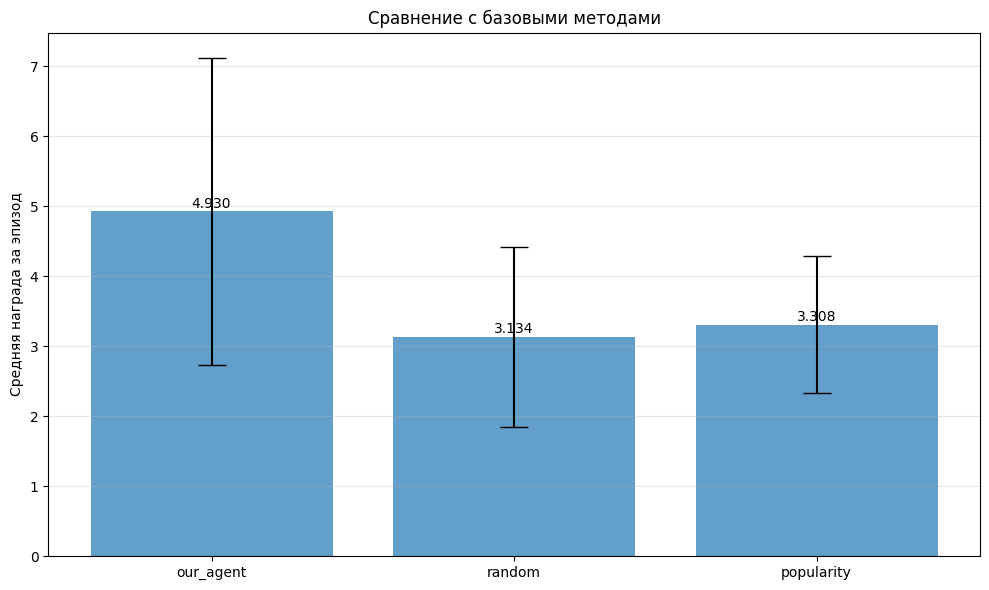


Результаты сравнения:
  our_agent: 4.930 ± 2.196
  random: 3.134 ± 1.281
  popularity: 3.308 ± 0.978

----------------------------------------
ЭКСПЕРИМЕНТ 3: ABLATION STUDY
----------------------------------------

----------------------------------------
ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
----------------------------------------


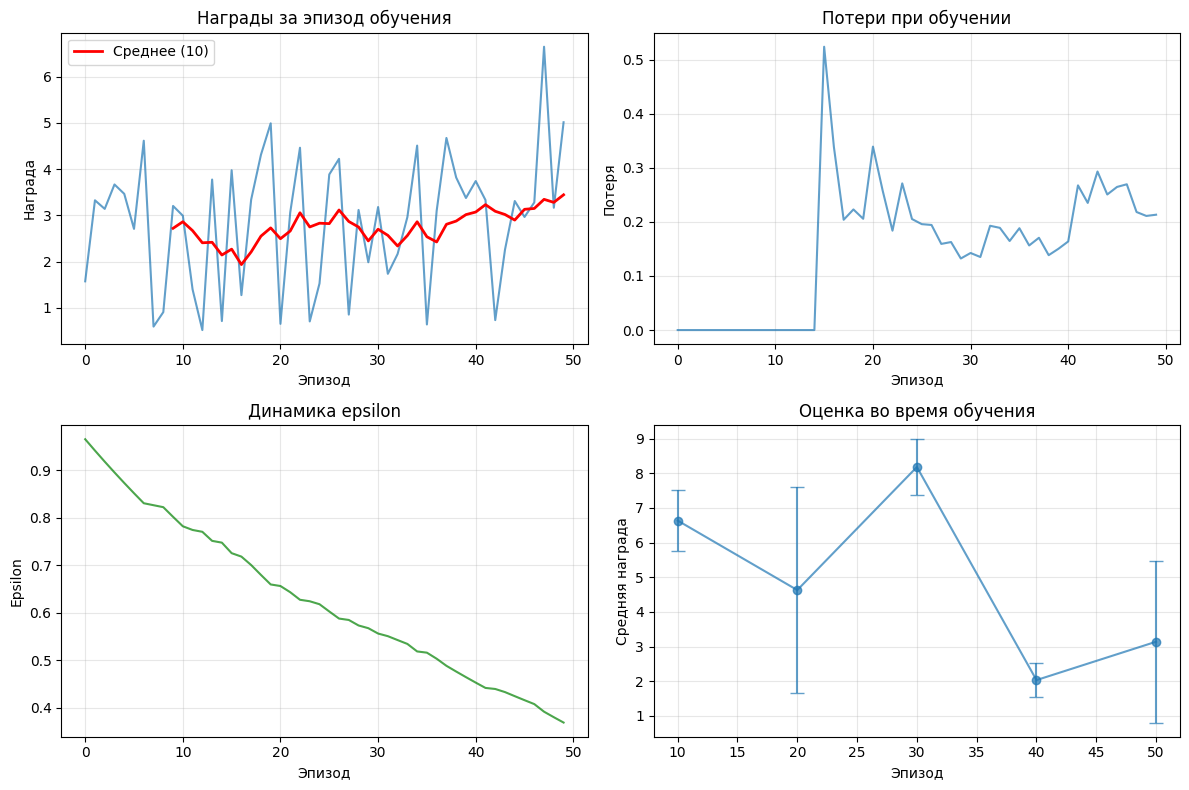


Сохранение результатов...

БАЗОВЫЕ ЭКСПЕРИМЕНТЫ ЗАВЕРШЕНЫ!


In [5]:
print("\n" + "="*50)
print("5. БАЗОВЫЕ ЭКСПЕРИМЕНТЫ ПО ВАЛИДАЦИИ")
print("="*50)

import matplotlib.pyplot as plt
from tqdm import tqdm
import json

class ExperimentRunner:
    """Запуск экспериментов по валидации"""
    def __init__(self, trainer, env):
        self.trainer = trainer
        self.env = env
        self.results = {
            'training_rewards': [],
            'training_losses': [],
            'evaluation_scores': [],
            'epsilon_values': []
        }
    
    def run_training_experiment(self, n_episodes=100, eval_interval=10):
        """Эксперимент по обучению"""
        print(f"Запуск обучения на {n_episodes} эпизодов...")
        
        for episode in tqdm(range(n_episodes)):
            # Обучение на одном эпизоде
            episode_reward, avg_loss = self.trainer.train_episode()
            
            # Сохранение результатов
            self.results['training_rewards'].append(episode_reward)
            self.results['training_losses'].append(avg_loss)
            self.results['epsilon_values'].append(self.trainer.epsilon)
            
            # Периодическая оценка
            if (episode + 1) % eval_interval == 0:
                eval_results = self.trainer.evaluate(n_episodes=3)
                self.results['evaluation_scores'].append({
                    'episode': episode + 1,
                    'mean_reward': eval_results['mean_reward'],
                    'std_reward': eval_results['std_reward']
                })
                
                print(f"\nЭпизод {episode + 1}:")
                print(f"  Награда обучения: {episode_reward:.3f}")
                print(f"  Средняя оценка: {eval_results['mean_reward']:.3f}")
                print(f"  Epsilon: {self.trainer.epsilon:.3f}")
        
        print("\nОбучение завершено!")
        return self.results
    
    def run_ablation_study(self, variants=['full', 'no_context', 'no_demo', 'no_novelty']):
        """Исследование важности компонентов"""
        print("Запуск ablation study...")
        
        ablation_results = {}
        
        for variant in variants:
            print(f"\nВариант: {variant}")
            
            # Создание модифицированной среды
            if variant == 'no_context':
                # Без контекстных признаков
                modified_env = self._create_env_without_context()
            elif variant == 'no_demo':
                # Без демографических признаков
                modified_env = self._create_env_without_demographics()
            elif variant == 'no_novelty':
                # Без компонента новизны
                modified_env = self._create_env_without_novelty()
            else:
                # Полная версия
                modified_env = self.env
            
            # Обучение агента с нуля
            agent = DuelingDQN(modified_env.state_dim, 70)
            buffer = PrioritizedReplayBuffer(capacity=10000)
            trainer = DQNTrainer(modified_env, agent, buffer, self.trainer.config)
            
            # Короткое обучение
            rewards = []
            for _ in range(20):
                episode_reward, _ = trainer.train_episode()
                rewards.append(episode_reward)
            
            # Оценка
            eval_results = trainer.evaluate(n_episodes=5)
            
            ablation_results[variant] = {
                'mean_training_reward': np.mean(rewards),
                'eval_mean_reward': eval_results['mean_reward'],
                'eval_std_reward': eval_results['std_reward']
            }
            
            print(f"  Средняя награда обучения: {np.mean(rewards):.3f}")
            print(f"  Средняя оценка: {eval_results['mean_reward']:.3f}")
        
        return ablation_results
    
    def compare_with_baselines(self):
        """Сравнение с базовыми методами"""
        print("\nСравнение с базовыми методами...")
        
        baselines = {
            'random': self._run_random_policy(),
            'popularity': self._run_popularity_policy()
        }
        
        # Оценка нашего агента
        our_agent_score = self.trainer.evaluate(n_episodes=10)
        
        comparison = {
            'our_agent': our_agent_score,
            'random': baselines['random'],
            'popularity': baselines['popularity']
        }
        
        # Визуализация сравнения
        self._plot_comparison(comparison)
        
        return comparison
    
    def _run_random_policy(self):
        """Случайная политика"""
        rewards = []
        for _ in range(10):
            state = self.env.reset()
            episode_reward = 0
            done = False
            
            while not done:
                action = np.random.randint(0, 70)
                next_state, reward, done, _ = self.env.step(action)
                episode_reward += reward
            
            rewards.append(episode_reward)
        
        return {
            'mean_reward': np.mean(rewards),
            'std_reward': np.std(rewards)
        }
    
    def _run_popularity_policy(self):
        """Политика популярности (рекомендует самые популярные темы)"""
        # Анализ популярности тем
        ratings = pd.read_csv('/kaggle/input/itmrec/ratings.csv')
        item_popularity = ratings['Item'].value_counts()
        popular_items = item_popularity.index[:10].tolist()
        
        rewards = []
        for _ in range(10):
            state = self.env.reset()
            episode_reward = 0
            done = False
            step = 0
            
            while not done:
                # Циклическая рекомендация популярных тем
                action = popular_items[step % len(popular_items)]
                next_state, reward, done, _ = self.env.step(action)
                episode_reward += reward
                step += 1
            
            rewards.append(episode_reward)
        
        return {
            'mean_reward': np.mean(rewards),
            'std_reward': np.std(rewards)
        }
    
    def _plot_comparison(self, comparison):
        """Визуализация сравнения методов"""
        methods = list(comparison.keys())
        means = [comparison[m]['mean_reward'] for m in methods]
        stds = [comparison[m].get('std_reward', 0) for m in methods]
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(methods, means, yerr=stds, capsize=10, alpha=0.7)
        plt.ylabel('Средняя награда за эпизод')
        plt.title('Сравнение с базовыми методами')
        plt.grid(True, alpha=0.3, axis='y')
        
        # Добавление значений на столбцы
        for bar, mean in zip(bars, means):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{mean:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    def plot_training_progress(self):
        """Визуализация прогресса обучения"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        
        # 1. Награды за эпизод
        axes[0, 0].plot(self.results['training_rewards'], alpha=0.7)
        axes[0, 0].set_title('Награды за эпизод обучения')
        axes[0, 0].set_xlabel('Эпизод')
        axes[0, 0].set_ylabel('Награда')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Скользящее среднее
        window = 10
        if len(self.results['training_rewards']) >= window:
            rolling_mean = pd.Series(self.results['training_rewards']).rolling(window).mean()
            axes[0, 0].plot(rolling_mean, 'r-', linewidth=2, label=f'Среднее ({window})')
            axes[0, 0].legend()
        
        # 2. Потери
        axes[0, 1].plot(self.results['training_losses'], alpha=0.7)
        axes[0, 1].set_title('Потери при обучении')
        axes[0, 1].set_xlabel('Эпизод')
        axes[0, 1].set_ylabel('Потеря')
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Epsilon
        axes[1, 0].plot(self.results['epsilon_values'], 'g-', alpha=0.7)
        axes[1, 0].set_title('Динамика epsilon')
        axes[1, 0].set_xlabel('Эпизод')
        axes[1, 0].set_ylabel('Epsilon')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. Оценка
        if self.results['evaluation_scores']:
            episodes = [score['episode'] for score in self.results['evaluation_scores']]
            eval_rewards = [score['mean_reward'] for score in self.results['evaluation_scores']]
            eval_stds = [score['std_reward'] for score in self.results['evaluation_scores']]
            
            axes[1, 1].errorbar(episodes, eval_rewards, yerr=eval_stds, 
                               fmt='o-', capsize=5, alpha=0.7)
            axes[1, 1].set_title('Оценка во время обучения')
            axes[1, 1].set_xlabel('Эпизод')
            axes[1, 1].set_ylabel('Средняя награда')
            axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Запуск экспериментов
print("Инициализация runner для экспериментов...")
experiment_runner = ExperimentRunner(trainer, env)

# Эксперимент 1: Обучение
print("\n" + "-"*40)
print("ЭКСПЕРИМЕНТ 1: ОБУЧЕНИЕ АГЕНТА")
print("-"*40)

training_results = experiment_runner.run_training_experiment(
    n_episodes=50,  # Для быстрого теста
    eval_interval=10
)

# Эксперимент 2: Сравнение с базовыми методами
print("\n" + "-"*40)
print("ЭКСПЕРИМЕНТ 2: СРАВНЕНИЕ С БАЗОВЫМИ МЕТОДАМИ")
print("-"*40)

comparison_results = experiment_runner.compare_with_baselines()

print("\nРезультаты сравнения:")
for method, scores in comparison_results.items():
    print(f"  {method}: {scores['mean_reward']:.3f} ± {scores.get('std_reward', 0):.3f}")

# Эксперимент 3: Ablation study (опционально)
print("\n" + "-"*40)
print("ЭКСПЕРИМЕНТ 3: ABLATION STUDY")
print("-"*40)

# ablation_results = experiment_runner.run_ablation_study()
# print("\nРезультаты ablation study:")
# for variant, results in ablation_results.items():
#     print(f"  {variant}: обучение={results['mean_training_reward']:.3f}, "
#           f"оценка={results['eval_mean_reward']:.3f}")

# Визуализация прогресса
print("\n" + "-"*40)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("-"*40)

experiment_runner.plot_training_progress()

# Сохранение результатов
print("\nСохранение результатов...")
results_to_save = {
    'training_summary': {
        'final_epsilon': trainer.epsilon,
        'total_episodes': len(training_results['training_rewards']),
        'mean_training_reward': np.mean(training_results['training_rewards'][-10:]),
        'best_evaluation': max([score['mean_reward'] 
                              for score in training_results['evaluation_scores']])
    },
    'comparison_results': comparison_results,
    'agent_config': {
        'state_dim': state_dim,
        'action_dim': action_dim,
        'training_config': train_config
    }
}

with open('/kaggle/working/experiment_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("\n" + "="*50)
print("БАЗОВЫЕ ЭКСПЕРИМЕНТЫ ЗАВЕРШЕНЫ!")
print("="*50)

In [6]:
# Полное обучение на 1000+ эпизодов
full_training_results = experiment_runner.run_training_experiment(
    n_episodes=200,
    eval_interval=50
)

Запуск обучения на 200 эпизодов...


  2%|▏         | 3/200 [00:00<00:09, 20.92it/s]

Эпизод начат: User 37, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 304, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 166, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 343, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 346, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 449, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 172, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 326, Context {'class': 1, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 430, Context {'class': 0, 'semester': 1, 'lockdown': 0}


  3%|▎         | 6/200 [00:00<00:11, 16.56it/s]

Эпизод начат: User 261, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 262, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 252, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 379, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 12, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 173, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 178, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 148, Context {'class': 0, 'semester': 0, 'lockdown': 2}


...

Эпизод начат: User 229, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 225, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 303, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 145, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 333, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 269, Context {'class': 0, 'semester': 0, 'lockdown': 2}


 98%|█████████▊| 197/200 [00:13<00:00, 12.77it/s]

Эпизод начат: User 328, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 342, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 427, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 289, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 60, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 350, Context {'class': 0, 'semester': 0, 'lockdown': 2}


100%|██████████| 200/200 [00:14<00:00, 14.24it/s]

Эпизод начат: User 312, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 60, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 244, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 17, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 18, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 133, Context {'class': 0, 'semester': 0, 'lockdown': 2}

Эпизод 200:
  Награда обучения: 5.683
  Средняя оценка: 5.873
  Epsilon: 0.010

Обучение завершено!


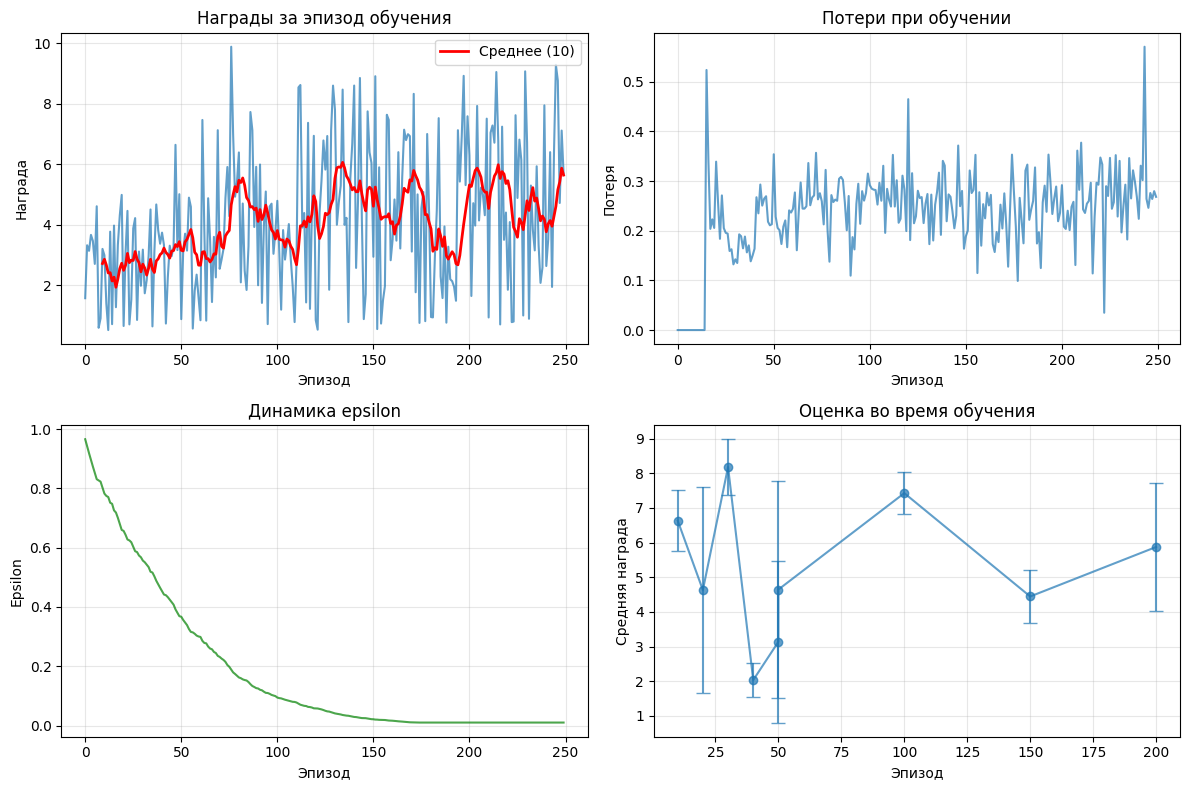

In [7]:
experiment_runner.plot_training_progress()

# Тестирование


Инициализация сравнительного тестирования...

Запуск тестов на 20 пользователях...
СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ МОДЕЛЕЙ

Пользователь 1/20

Пользователь 2/20
  Random: Precision=0.200, Reward=0.666
  Popularity: Precision=0.100, Reward=0.687
  DeepFM-SVD++ (Static): Precision=0.100, Reward=0.784
Эпизод начат: User 1, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 1, Context {'class': 0, 'semester': 0, 'lockdown': 0}
  DQN-Enhanced: Precision=0.000, Reward=4.108

Пользователь 3/20

Пользователь 4/20

Пользователь 5/20
  Random: Precision=0.000, Reward=0.632
  Popularity: Precision=0.300, Reward=0.638
  DeepFM-SVD++ (Static): Precision=0.000, Reward=0.767
Эпизод начат: User 4, Context {'class': 2, 'semester': 1, 'lockdown': 0}
Эпизод начат: User 4, Context {'class': 2, 'semester': 1, 'lockdown': 0}
  DQN-Enhanced: Precision=0.250, Reward=3.365

Пользователь 6/20
  Random: Precision=0.200, Reward=0.645
  Popularity: Precision=0.000, Reward=0.679
  DeepFM-SVD++ (Stati

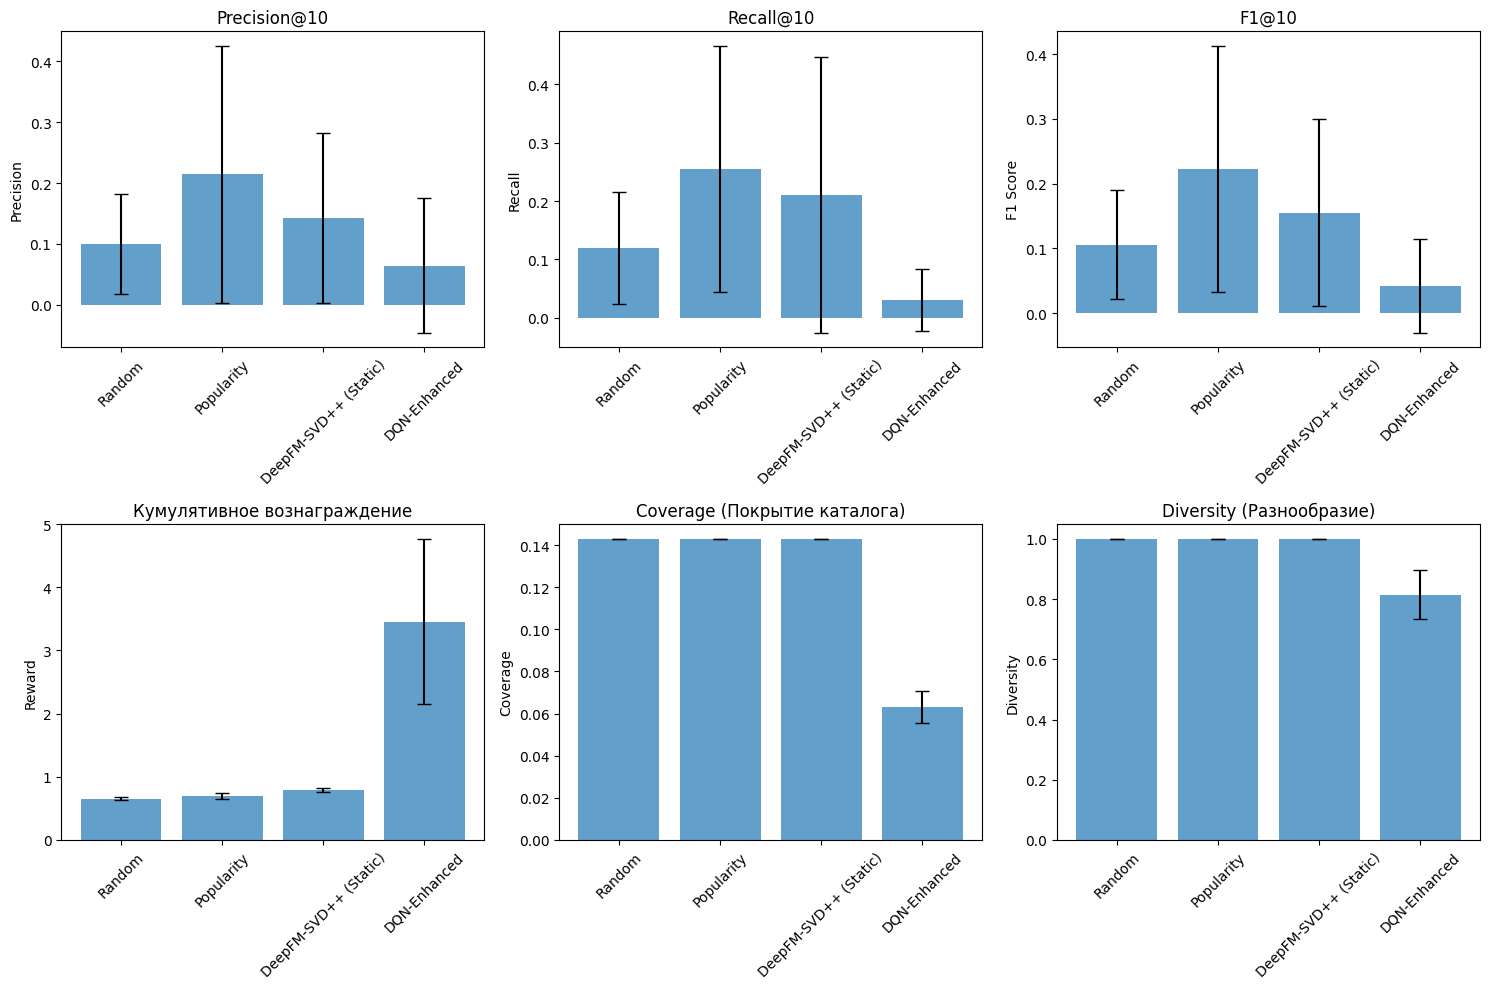


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                Model  Precision@10     Recall@10         F1@10 Cumulative_Reward      Coverage     Diversity
               Random 0.100 ± 0.082 0.120 ± 0.095 0.106 ± 0.084     0.652 ± 0.021 0.143 ± 0.000 1.000 ± 0.000
           Popularity 0.214 ± 0.212 0.255 ± 0.211 0.223 ± 0.190     0.695 ± 0.042 0.143 ± 0.000 1.000 ± 0.000
DeepFM-SVD++ (Static) 0.143 ± 0.140 0.211 ± 0.237 0.155 ± 0.145     0.790 ± 0.028 0.143 ± 0.000 1.000 ± 0.000
         DQN-Enhanced 0.064 ± 0.111 0.031 ± 0.054 0.042 ± 0.072     3.456 ± 1.309 0.063 ± 0.008 0.814 ± 0.081

АНАЛИЗ КОРРЕЛЯЦИЙ МЕТРИК


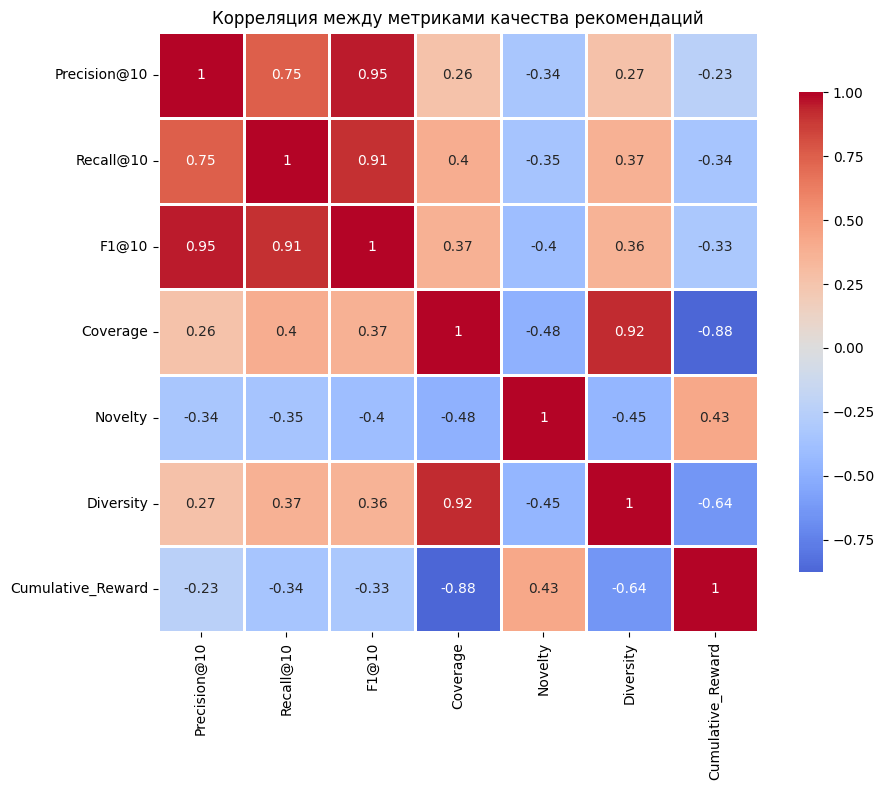


АНАЛИЗ ПО ПОЛЬЗОВАТЕЛЬСКИМ СЕГМЕНТАМ
Эпизод начат: User 160, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 160, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 141, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 141, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 296, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 296, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 244, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 244, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 28, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 28, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 160, Context {'class': 1, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 160, Context {'class': 1, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 141, Context {'class': 1, 'semester': 0, 'loc

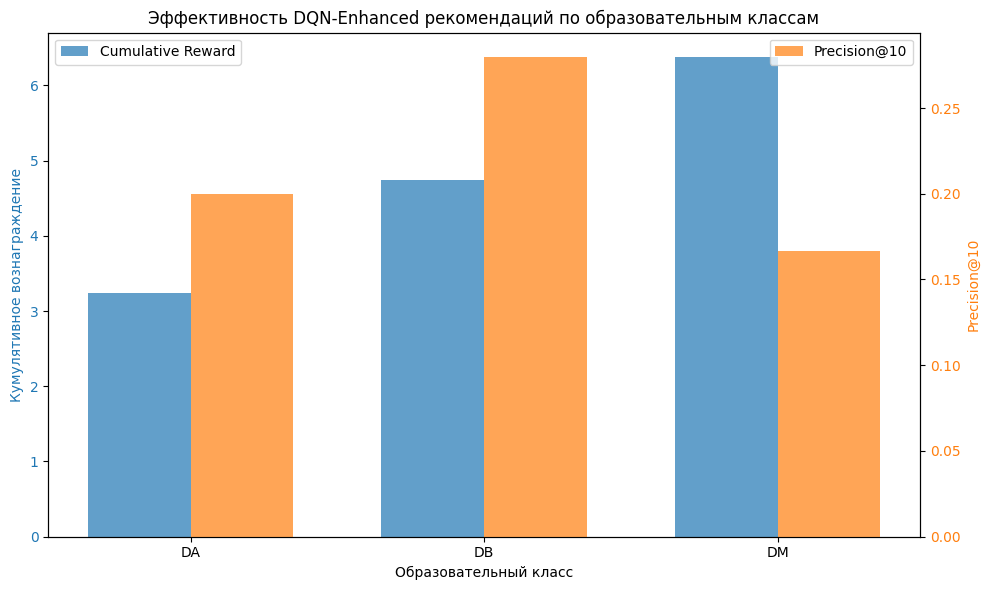


СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!


In [8]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns

class ComparativeTester:
    """Класс для сравнительного тестирования всех моделей"""
    
    def __init__(self, env, deepfm_model, dqn_agent, dataset):
        self.env = env
        self.deepfm_model = deepfm_model
        self.dqn_agent = dqn_agent
        self.dataset = dataset
        self.n_items = dataset.n_items
        
        # Базовые модели
        self.baseline_models = {
            'Random': self.random_recommender,
            'Popularity': self.popularity_recommender,
            'DeepFM-SVD++ (Static)': self.static_deepfm_recommender,
            'DQN-Enhanced': self.dqn_recommender
        }
        
        # Статистика популярности предметов
        self._compute_item_popularity()
    
    def _compute_item_popularity(self):
        """Вычисление популярности предметов"""
        ratings = pd.read_csv('/kaggle/input/itmrec/ratings.csv')
        self.item_popularity = ratings['Item'].value_counts().to_dict()
        
        # Нормализация популярности
        max_pop = max(self.item_popularity.values())
        self.item_popularity_norm = {
            item: count/max_pop for item, count in self.item_popularity.items()
        }
    
    def random_recommender(self, user_id, context, k=10):
        """Случайный рекомендатель"""
        return np.random.choice(self.n_items, k, replace=False)
    
    def popularity_recommender(self, user_id, context, k=10):
        """Рекомендатель на основе популярности"""
        # Сортируем предметы по популярности
        sorted_items = sorted(
            self.item_popularity.items(), 
            key=lambda x: x[1], 
            reverse=True
        )
        return [item[0] for item in sorted_items[:k]]
    
    def static_deepfm_recommender(self, user_id, context, k=10):
        """Статичный DeepFM-SVD++ рекомендатель"""
        device = self.deepfm_model.device
        
        # Создание тензоров для всех предметов
        item_ids = torch.arange(self.n_items).long().to(device)
        user_ids = torch.LongTensor([user_id] * self.n_items).to(device)
        class_ids = torch.LongTensor([context['class']] * self.n_items).to(device)
        semester_ids = torch.LongTensor([context['semester']] * self.n_items).to(device)
        lockdown_ids = torch.LongTensor([context['lockdown']] * self.n_items).to(device)
        
        with torch.no_grad():
            # Получение предсказаний для всех предметов
            predictions = self.deepfm_model(
                user_ids, item_ids, class_ids, semester_ids, lockdown_ids
            )
            
            # Комбинирование мультикритериальных оценок
            scores = (
                0.5 * predictions['rating'] + 
                0.3 * predictions['app'] + 
                0.15 * predictions['data'] + 
                0.05 * predictions['ease']
            )
        
        # Выбор топ-k предметов
        top_indices = torch.topk(scores, k).indices.cpu().numpy()
        return top_indices
    
    def dqn_recommender(self, user_id, context, k=10):
        """DQN-улучшенный рекомендатель"""
        state = self.env.reset(user_id=user_id, context=context)
        
        recommended_items = []
        
        for _ in range(k):
            action = self.dqn_agent.get_action(state, epsilon=0.01)
            recommended_items.append(action)
            
            # Обновление состояния (без реального взаимодействия)
            next_state, _, done, _ = self.env.step(action)
            state = next_state
            
            if done:
                break
        
        return recommended_items
    
    def calculate_metrics(self, recommendations, ground_truth, k=10):
        """Расчет всех метрик качества"""
        metrics = {}
        
        # Precision@k, Recall@k, F1@k
        y_true = np.zeros(self.n_items)
        y_pred = np.zeros(self.n_items)
        
        y_true[list(ground_truth)] = 1
        y_pred[recommendations[:k]] = 1
        
        # Для бинарных метрик нужны фактические релевантные предметы
        # В реальном сценарии ground_truth - это предметы, которые пользователь оценил высоко
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0) if (precision + recall) > 0 else 0
        
        metrics['Precision@10'] = precision
        metrics['Recall@10'] = recall
        metrics['F1@10'] = f1
        
        # Coverage (покрытие каталога)
        metrics['Coverage'] = len(set(recommendations)) / self.n_items
        
        # Novelty (новизна - обратная популярность)
        novelty_scores = []
        for item in recommendations[:k]:
            if item in self.item_popularity_norm:
                novelty_scores.append(1 - self.item_popularity_norm[item])
            else:
                novelty_scores.append(1.0)
        metrics['Novelty'] = np.mean(novelty_scores) if novelty_scores else 0
        
        # Diversity (разнообразие рекомендаций)
        if len(recommendations) >= 2:
            diversity = 0
            count = 0
            for i in range(len(recommendations)):
                for j in range(i+1, len(recommendations)):
                    # Простая метрика разнообразия (можно заменить на косинусное расстояние)
                    diversity += 1 if recommendations[i] != recommendations[j] else 0
                    count += 1
            metrics['Diversity'] = diversity / count if count > 0 else 0
        else:
            metrics['Diversity'] = 0
        
        return metrics
    
    def run_comparative_test(self, test_users=20, recommendations_per_user=10):
        """Запуск сравнительного тестирования"""
        
        results = {model_name: [] for model_name in self.baseline_models.keys()}
        
        print("="*60)
        print("СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ МОДЕЛЕЙ")
        print("="*60)
        
        for i, user_id in enumerate(range(test_users)):
            if i >= test_users:
                break
            
            print(f"\nПользователь {i+1}/{test_users}")
            
            # Случайный контекст
            context = {
                'class': np.random.randint(0, 3),
                'semester': np.random.randint(0, 2),
                'lockdown': np.random.randint(0, 3)
            }
            
            # "Правда" - предметы, которые пользователь оценил высоко (рейтинг > 3)
            user_ratings = self.dataset.ratings[
                self.dataset.ratings['UserID_encoded'] == user_id
            ]
            ground_truth = user_ratings[
                user_ratings['Rating'] > 3
            ]['ItemID_encoded'].tolist()[:20]  # Берем до 20 высокооцененных
            
            if len(ground_truth) < 5:
                continue  # Пропускаем пользователей с недостаточной историей
            
            for model_name, model_func in self.baseline_models.items():
                try:
                    # Получение рекомендаций
                    recommendations = model_func(user_id, context, k=recommendations_per_user)
                    
                    # Расчет метрик
                    metrics = self.calculate_metrics(recommendations, ground_truth, k=10)
                    
                    # Добавление кумулятивного вознаграждения для RL моделей
                    if model_name == 'DQN-Enhanced':
                        cumulative_reward = self._evaluate_dqn_trajectory(user_id, context)
                        metrics['Cumulative_Reward'] = cumulative_reward
                    else:
                        metrics['Cumulative_Reward'] = self._simulate_reward(
                            recommendations, user_id, context
                        )
                    
                    results[model_name].append(metrics)
                    
                    print(f"  {model_name}: Precision={metrics['Precision@10']:.3f}, "
                          f"Reward={metrics['Cumulative_Reward']:.3f}")
                    
                except Exception as e:
                    print(f"  Ошибка в {model_name}: {e}")
                    continue
        
        # Агрегация результатов
        aggregated_results = {}
        for model_name, metrics_list in results.items():
            if metrics_list:
                df = pd.DataFrame(metrics_list)
                aggregated_results[model_name] = {
                    'mean': df.mean(),
                    'std': df.std(),
                    'data': df
                }
        
        return aggregated_results
    
    def _evaluate_dqn_trajectory(self, user_id, context, max_steps=10):
        """Оценка траектории DQN агента"""
        state = self.env.reset(user_id=user_id, context=context)
        cumulative_reward = 0
        
        for step in range(max_steps):
            action = self.dqn_agent.get_action(state, epsilon=0.01)
            next_state, reward, done, _ = self.env.step(action)
            cumulative_reward += reward
            state = next_state
            
            if done:
                break
        
        return cumulative_reward
    
    def _simulate_reward(self, recommendations, user_id, context):
        """Симуляция вознаграждения для не-RL моделей"""
        total_reward = 0
        
        for item in recommendations[:10]:
            # Используем средний рейтинг пользователя для предмета
            user_ratings = self.dataset.ratings[
                (self.dataset.ratings['UserID_encoded'] == user_id) & 
                (self.dataset.ratings['ItemID_encoded'] == item)
            ]
            
            if not user_ratings.empty:
                reward = user_ratings['Rating'].mean() / 5.0  # Нормализация к [0,1]
            else:
                # Используем среднее по всем пользователям
                all_ratings = self.dataset.ratings[
                    self.dataset.ratings['ItemID_encoded'] == item
                ]
                reward = all_ratings['Rating'].mean() / 5.0 if not all_ratings.empty else 0.5
            
            total_reward += reward
        
        return total_reward / min(len(recommendations), 10)
    
    def visualize_results(self, aggregated_results):
        """Визуализация результатов тестирования"""
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        # Подготовка данных для визуализации
        models = list(aggregated_results.keys())
        
        # 1. Precision@10
        precisions = [aggregated_results[m]['mean']['Precision@10'] for m in models]
        precisions_std = [aggregated_results[m]['std']['Precision@10'] for m in models]
        
        axes[0].bar(models, precisions, yerr=precisions_std, capsize=5, alpha=0.7)
        axes[0].set_title('Precision@10')
        axes[0].set_ylabel('Precision')
        axes[0].tick_params(axis='x', rotation=45)
        
        # 2. Recall@10
        recalls = [aggregated_results[m]['mean']['Recall@10'] for m in models]
        recalls_std = [aggregated_results[m]['std']['Recall@10'] for m in models]
        
        axes[1].bar(models, recalls, yerr=recalls_std, capsize=5, alpha=0.7)
        axes[1].set_title('Recall@10')
        axes[1].set_ylabel('Recall')
        axes[1].tick_params(axis='x', rotation=45)
        
        # 3. F1@10
        f1_scores = [aggregated_results[m]['mean']['F1@10'] for m in models]
        f1_std = [aggregated_results[m]['std']['F1@10'] for m in models]
        
        axes[2].bar(models, f1_scores, yerr=f1_std, capsize=5, alpha=0.7)
        axes[2].set_title('F1@10')
        axes[2].set_ylabel('F1 Score')
        axes[2].tick_params(axis='x', rotation=45)
        
        # 4. Кумулятивное вознаграждение
        rewards = [aggregated_results[m]['mean']['Cumulative_Reward'] for m in models]
        rewards_std = [aggregated_results[m]['std']['Cumulative_Reward'] for m in models]
        
        axes[3].bar(models, rewards, yerr=rewards_std, capsize=5, alpha=0.7)
        axes[3].set_title('Кумулятивное вознаграждение')
        axes[3].set_ylabel('Reward')
        axes[3].tick_params(axis='x', rotation=45)
        
        # 5. Coverage
        coverages = [aggregated_results[m]['mean']['Coverage'] for m in models]
        coverages_std = [aggregated_results[m]['std']['Coverage'] for m in models]
        
        axes[4].bar(models, coverages, yerr=coverages_std, capsize=5, alpha=0.7)
        axes[4].set_title('Coverage (Покрытие каталога)')
        axes[4].set_ylabel('Coverage')
        axes[4].tick_params(axis='x', rotation=45)
        
        # 6. Diversity
        diversities = [aggregated_results[m]['mean']['Diversity'] for m in models]
        diversities_std = [aggregated_results[m]['std']['Diversity'] for m in models]
        
        axes[5].bar(models, diversities, yerr=diversities_std, capsize=5, alpha=0.7)
        axes[5].set_title('Diversity (Разнообразие)')
        axes[5].set_ylabel('Diversity')
        axes[5].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Создание сводной таблицы
        summary_data = []
        for model_name in models:
            mean_metrics = aggregated_results[model_name]['mean']
            std_metrics = aggregated_results[model_name]['std']
            
            row = {
                'Model': model_name,
                'Precision@10': f"{mean_metrics['Precision@10']:.3f} ± {std_metrics['Precision@10']:.3f}",
                'Recall@10': f"{mean_metrics['Recall@10']:.3f} ± {std_metrics['Recall@10']:.3f}",
                'F1@10': f"{mean_metrics['F1@10']:.3f} ± {std_metrics['F1@10']:.3f}",
                'Cumulative_Reward': f"{mean_metrics['Cumulative_Reward']:.3f} ± {std_metrics['Cumulative_Reward']:.3f}",
                'Coverage': f"{mean_metrics['Coverage']:.3f} ± {std_metrics['Coverage']:.3f}",
                'Diversity': f"{mean_metrics['Diversity']:.3f} ± {std_metrics['Diversity']:.3f}"
            }
            summary_data.append(row)
        
        summary_df = pd.DataFrame(summary_data)
        
        print("\n" + "="*100)
        print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
        print("="*100)
        print(summary_df.to_string(index=False))
        
        return summary_df

# Запуск сравнительного тестирования
print("\nИнициализация сравнительного тестирования...")
tester = ComparativeTester(env, model, dqn_agent, dataset)

print("\nЗапуск тестов на 20 пользователях...")
aggregated_results = tester.run_comparative_test(
    test_users=20,
    recommendations_per_user=10
)

print("\nВизуализация результатов...")
summary_df = tester.visualize_results(aggregated_results)

# Дополнительный анализ: тепловая карта корреляций
print("\n" + "="*60)
print("АНАЛИЗ КОРРЕЛЯЦИЙ МЕТРИК")
print("="*60)

# Собираем все метрики в один DataFrame
all_metrics = []
for model_name, results in aggregated_results.items():
    df = results['data'].copy()
    df['Model'] = model_name
    all_metrics.append(df)

all_metrics_df = pd.concat(all_metrics, ignore_index=True)

# Тепловая карта корреляций
correlation_matrix = all_metrics_df.drop(columns=['Model']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляция между метриками качества рекомендаций')
plt.tight_layout()
plt.show()

# Анализ по пользовательским сегментам
print("\n" + "="*60)
print("АНАЛИЗ ПО ПОЛЬЗОВАТЕЛЬСКИМ СЕГМЕНТАМ")
print("="*60)

# Пример: сравнение моделей для разных образовательных классов
class_results = {}
for class_id in range(3):  # DA, DB, DM
    class_name = ['DA', 'DB', 'DM'][class_id]
    class_users = dataset.ratings[
        dataset.ratings['Class_encoded'] == class_id
    ]['UserID_encoded'].unique()[:5]  # Берем по 5 пользователей каждого класса
    
    if len(class_users) == 0:
        continue
    
    class_metrics = {model: [] for model in aggregated_results.keys()}
    
    for user_id in class_users:
        context = {'class': class_id, 'semester': 0, 'lockdown': 0}
        
        # Аналогично основному тестированию, но только для DQN для скорости
        recommendations = tester.dqn_recommender(user_id, context, k=10)
        user_ratings = dataset.ratings[
            dataset.ratings['UserID_encoded'] == user_id
        ]
        ground_truth = user_ratings[
            user_ratings['Rating'] > 3
        ]['ItemID_encoded'].tolist()[:20]
        
        if len(ground_truth) >= 5:
            metrics = tester.calculate_metrics(recommendations, ground_truth, k=10)
            metrics['Cumulative_Reward'] = tester._evaluate_dqn_trajectory(
                user_id, context
            )
            class_metrics['DQN-Enhanced'].append(metrics)
    
    # Усреднение по пользователям класса
    if class_metrics['DQN-Enhanced']:
        df = pd.DataFrame(class_metrics['DQN-Enhanced'])
        class_results[class_name] = {
            'mean_reward': df['Cumulative_Reward'].mean(),
            'mean_precision': df['Precision@10'].mean(),
            'n_users': len(df)
        }

# Визуализация результатов по классам
if class_results:
    classes = list(class_results.keys())
    rewards = [class_results[c]['mean_reward'] for c in classes]
    precisions = [class_results[c]['mean_precision'] for c in classes]
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(classes))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, rewards, width, label='Cumulative Reward', alpha=0.7)
    ax1.set_xlabel('Образовательный класс')
    ax1.set_ylabel('Кумулятивное вознаграждение', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, precisions, width, label='Precision@10', color='tab:orange', alpha=0.7)
    ax2.set_ylabel('Precision@10', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(classes)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.title('Эффективность DQN-Enhanced рекомендаций по образовательным классам')
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!")
print("="*60)


Инициализация сравнительного тестирования...

Запуск тестов на 20 пользователях...
СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ МОДЕЛЕЙ

Пользователь 1/20

Пользователь 2/20
  Random: Precision=0.000, Reward=0.646
  Popularity: Precision=0.100, Reward=0.687
  DeepFM-SVD++ (Static): Precision=0.200, Reward=0.805
Эпизод начат: User 1, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 1, Context {'class': 2, 'semester': 0, 'lockdown': 2}
  DQN-Enhanced: Precision=0.000, Reward=6.221

Пользователь 3/20

Пользователь 4/20

Пользователь 5/20
  Random: Precision=0.100, Reward=0.687
  Popularity: Precision=0.300, Reward=0.638
  DeepFM-SVD++ (Static): Precision=0.400, Reward=0.864
Эпизод начат: User 4, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 4, Context {'class': 0, 'semester': 0, 'lockdown': 2}
  DQN-Enhanced: Precision=0.400, Reward=0.585

Пользователь 6/20
  Random: Precision=0.100, Reward=0.656
  Popularity: Precision=0.000, Reward=0.679
  DeepFM-SVD++ (Stati

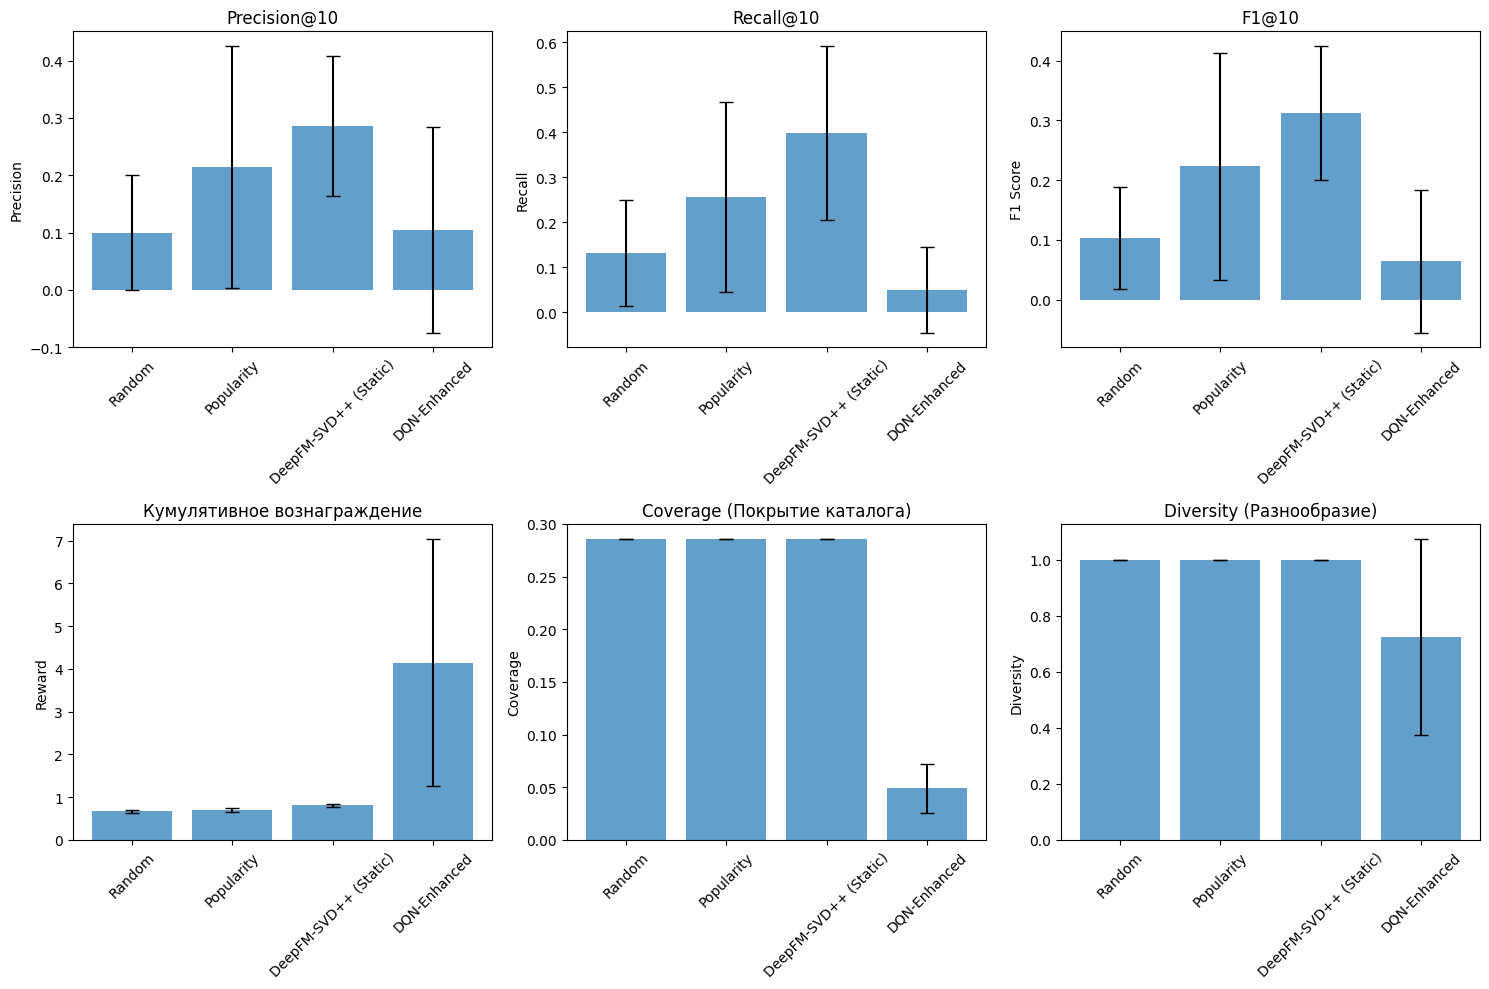


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                Model  Precision@10     Recall@10         F1@10 Cumulative_Reward      Coverage     Diversity
               Random 0.100 ± 0.100 0.131 ± 0.118 0.104 ± 0.085     0.676 ± 0.035 0.286 ± 0.000 1.000 ± 0.000
           Popularity 0.214 ± 0.212 0.255 ± 0.211 0.223 ± 0.190     0.695 ± 0.042 0.286 ± 0.000 1.000 ± 0.000
DeepFM-SVD++ (Static) 0.286 ± 0.121 0.398 ± 0.194 0.313 ± 0.112     0.814 ± 0.037 0.286 ± 0.000 1.000 ± 0.000
         DQN-Enhanced 0.105 ± 0.180 0.049 ± 0.095 0.064 ± 0.120     4.149 ± 2.890 0.049 ± 0.023 0.724 ± 0.351

АНАЛИЗ КОРРЕЛЯЦИЙ МЕТРИК


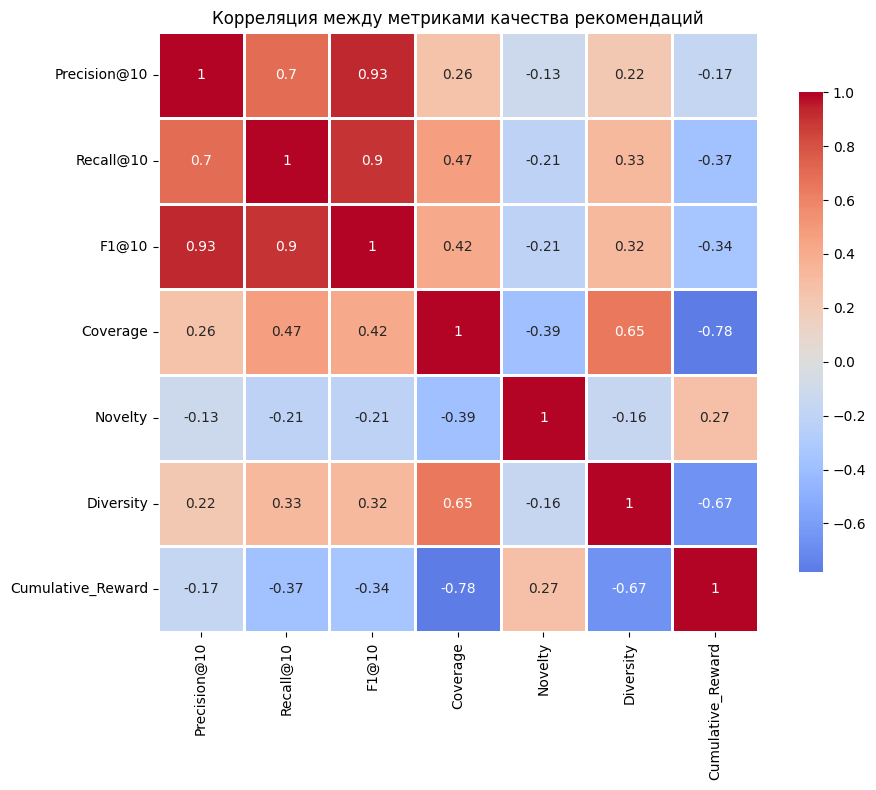


АНАЛИЗ ПО ПОЛЬЗОВАТЕЛЬСКИМ СЕГМЕНТАМ
Эпизод начат: User 160, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 160, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 141, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 141, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 296, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 296, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 244, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 244, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 28, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 28, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 160, Context {'class': 1, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 160, Context {'class': 1, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 141, Context {'class': 1, 'semester': 0, 'loc

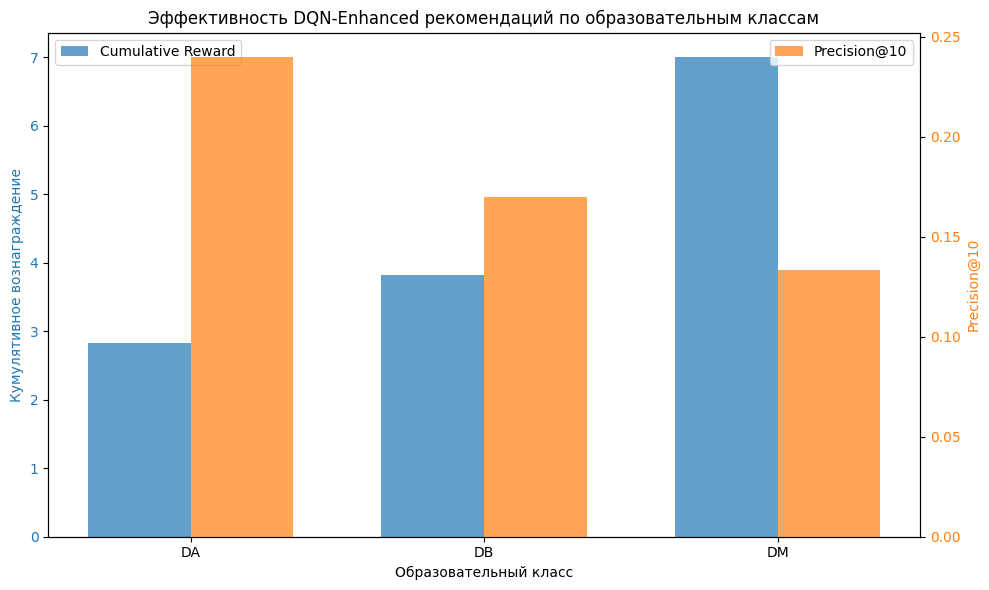


СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!


In [9]:
# Запуск сравнительного тестирования
print("\nИнициализация сравнительного тестирования...")
tester = ComparativeTester(env, model, dqn_agent, dataset)

print("\nЗапуск тестов на 20 пользователях...")
aggregated_results = tester.run_comparative_test(
    test_users=20,
    recommendations_per_user=20
)

print("\nВизуализация результатов...")
summary_df = tester.visualize_results(aggregated_results)

# Дополнительный анализ: тепловая карта корреляций
print("\n" + "="*60)
print("АНАЛИЗ КОРРЕЛЯЦИЙ МЕТРИК")
print("="*60)

# Собираем все метрики в один DataFrame
all_metrics = []
for model_name, results in aggregated_results.items():
    df = results['data'].copy()
    df['Model'] = model_name
    all_metrics.append(df)

all_metrics_df = pd.concat(all_metrics, ignore_index=True)

# Тепловая карта корреляций
correlation_matrix = all_metrics_df.drop(columns=['Model']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляция между метриками качества рекомендаций')
plt.tight_layout()
plt.show()

# Анализ по пользовательским сегментам
print("\n" + "="*60)
print("АНАЛИЗ ПО ПОЛЬЗОВАТЕЛЬСКИМ СЕГМЕНТАМ")
print("="*60)

# Пример: сравнение моделей для разных образовательных классов
class_results = {}
for class_id in range(3):  # DA, DB, DM
    class_name = ['DA', 'DB', 'DM'][class_id]
    class_users = dataset.ratings[
        dataset.ratings['Class_encoded'] == class_id
    ]['UserID_encoded'].unique()[:5]  # Берем по 5 пользователей каждого класса
    
    if len(class_users) == 0:
        continue
    
    class_metrics = {model: [] for model in aggregated_results.keys()}
    
    for user_id in class_users:
        context = {'class': class_id, 'semester': 0, 'lockdown': 0}
        
        # Аналогично основному тестированию, но только для DQN для скорости
        recommendations = tester.dqn_recommender(user_id, context, k=10)
        user_ratings = dataset.ratings[
            dataset.ratings['UserID_encoded'] == user_id
        ]
        ground_truth = user_ratings[
            user_ratings['Rating'] > 3
        ]['ItemID_encoded'].tolist()[:20]
        
        if len(ground_truth) >= 5:
            metrics = tester.calculate_metrics(recommendations, ground_truth, k=10)
            metrics['Cumulative_Reward'] = tester._evaluate_dqn_trajectory(
                user_id, context
            )
            class_metrics['DQN-Enhanced'].append(metrics)
    
    # Усреднение по пользователям класса
    if class_metrics['DQN-Enhanced']:
        df = pd.DataFrame(class_metrics['DQN-Enhanced'])
        class_results[class_name] = {
            'mean_reward': df['Cumulative_Reward'].mean(),
            'mean_precision': df['Precision@10'].mean(),
            'n_users': len(df)
        }

# Визуализация результатов по классам
if class_results:
    classes = list(class_results.keys())
    rewards = [class_results[c]['mean_reward'] for c in classes]
    precisions = [class_results[c]['mean_precision'] for c in classes]
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(classes))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, rewards, width, label='Cumulative Reward', alpha=0.7)
    ax1.set_xlabel('Образовательный класс')
    ax1.set_ylabel('Кумулятивное вознаграждение', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, precisions, width, label='Precision@10', color='tab:orange', alpha=0.7)
    ax2.set_ylabel('Precision@10', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(classes)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.title('Эффективность DQN-Enhanced рекомендаций по образовательным классам')
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("СРАВНИТЕЛЬНОЕ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!")
print("="*60)

In [10]:
def evaluate_long_term_performance(model, env, n_episodes=50, trajectory_length=100):
    """Оценка долгосрочной полезности на длинных траекториях"""
    all_precisions = []
    all_recalls = []
    all_f1_scores = []
    
    for episode in range(n_episodes):
        state = env.reset()
        recommended_items = []
        relevant_items = []
        
        for step in range(trajectory_length):
            # Рекомендация
            action = model.get_action(state, epsilon=0.01)
            recommended_items.append(action)
            
            # Симуляция отклика
            next_state, reward, done, info = env.step(action)
            
            # Сбор ground truth (предметы с высоким рейтингом в этом эпизоде)
            if reward > 0.7:  # Высокое вознаграждение = релевантный предмет
                relevant_items.append(action)
            
            state = next_state
            if done:
                break
        
        # Расчет метрик для длинной траектории
        # Precision@K: какие из рекомендованных были релевантны
        k = min(50, len(recommended_items))  # Смотрим на длинные рекомендации
        true_positives = len(set(recommended_items[:k]) & set(relevant_items))
        
        precision = true_positives / k if k > 0 else 0
        recall = true_positives / len(relevant_items) if relevant_items else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        all_precisions.append(precision)
        all_recalls.append(recall)
        all_f1_scores.append(f1)
    
    return {
        'precision_mean': np.mean(all_precisions),
        'precision_std': np.std(all_precisions),
        'precision_all': all_precisions,
        'recall_mean': np.mean(all_recalls),
        'recall_std': np.std(all_recalls),
        'recall_all': all_recalls,
        'f1_mean': np.mean(all_f1_scores),
        'f1_std': np.std(all_f1_scores),
        'f1': all_f1_scores,
    }

In [11]:
res = evaluate_long_term_performance(dqn_agent, env)

Эпизод начат: User 445, Context {'class': 1, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 104, Context {'class': 0, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 379, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 333, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 390, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 207, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 119, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 240, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 428, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 259, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 122, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 171, Context {'class': 1, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 265, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 386, C

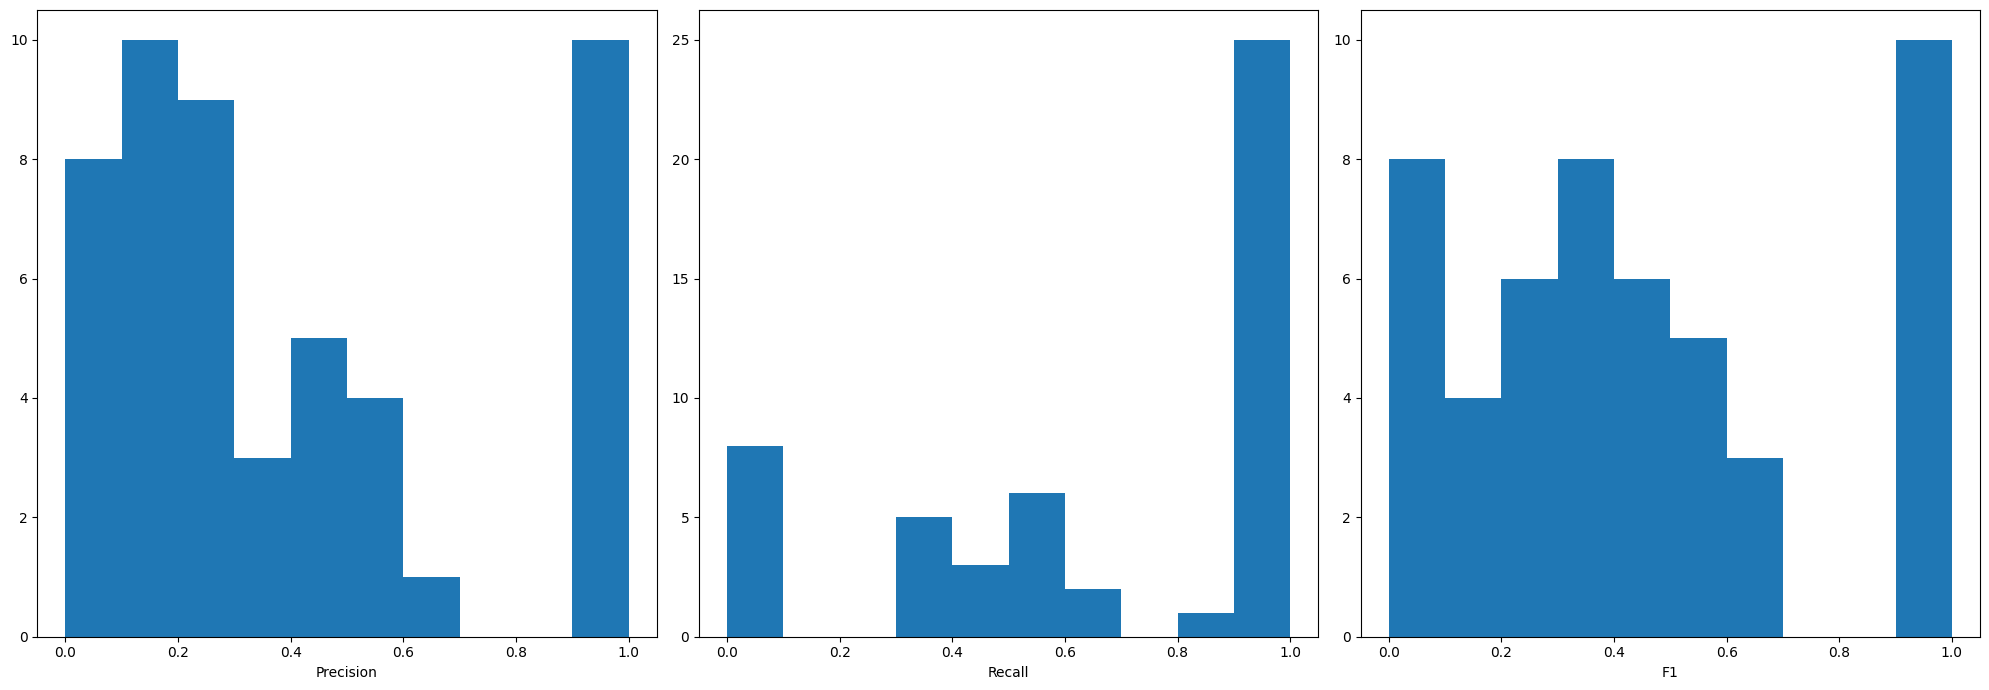

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 7))

ax[0].hist(res['precision_all'])
ax[0].set_xlabel('Precision')

ax[1].hist(res['recall_all'])
ax[1].set_xlabel('Recall')

ax[2].hist(res['f1'])
ax[2].set_xlabel('F1')
plt.tight_layout()
plt.show()

In [13]:
print(f"Precision: {res['precision_mean']:.3f} ± {res['precision_std']:.3f}")
print(f"Recall: {res['recall_mean']:.3f} ± {res['recall_std']:.3f}")
print(f"Precision: {res['f1_mean']:.3f} ± {res['f1_std']:.3f}")

Precision: 0.389 ± 0.344
Recall: 0.665 ± 0.380
Precision: 0.441 ± 0.332


In [14]:
def evaluate_adaptability(model, env, preference_shifts=3):
    """Оценка способности адаптироваться к изменяющимся предпочтениям"""
    
    results = []
    
    for shift in range(preference_shifts):
        # Симуляция изменения предпочтений пользователя
        env.current_context = {
            'class': np.random.randint(0, 3),
            'semester': (env.current_context['semester'] + 1) % 2,  # Смена семестра
            'lockdown': np.random.randint(0, 3)
        }
        
        # Оценка после смены предпочтений
        eval_results = evaluate_long_term_performance(
            model, env, n_episodes=10, trajectory_length=30
        )
        eval_results['shift'] = shift
        results.append(eval_results)
    
    # Анализ устойчивости метрик
    precisions = [r['precision_mean'] for r in results]
    recalls = [r['recall_mean'] for r in results]
    
    adaptability_score = 1 - (np.std(precisions) + np.std(recalls)) / 2
    
    return {
        'results': results,
        'adaptability_score': adaptability_score,
        'precision_stability': np.std(precisions),
        'recall_stability': np.std(recalls)
    }

In [15]:
res_2 = evaluate_adaptability(dqn_agent, env)

Эпизод начат: User 288, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 90, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 435, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 377, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 352, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 424, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 48, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 44, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 166, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 163, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 270, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 153, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 384, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 88, Conte

In [16]:
print(f"Адаптивность агента: {res_2['adaptability_score']}")
print(f"Стбильность Precision: {res_2['precision_stability']}")
print(f"Стабильность Recall: {res_2['recall_stability']}")

Адаптивность агента: 0.9383870162275739
Стбильность Precision: 0.0471990887862397
Стабильность Recall: 0.07602687875861255


Запуск долгосрочной оценки полезности...

Тестирование DQN...
Эпизод начат: User 0, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 1, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 2, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 3, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 4, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 5, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 6, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 7, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 8, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 9, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 10, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 11, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 12, Context {'class': 0, 'semester': 0, '

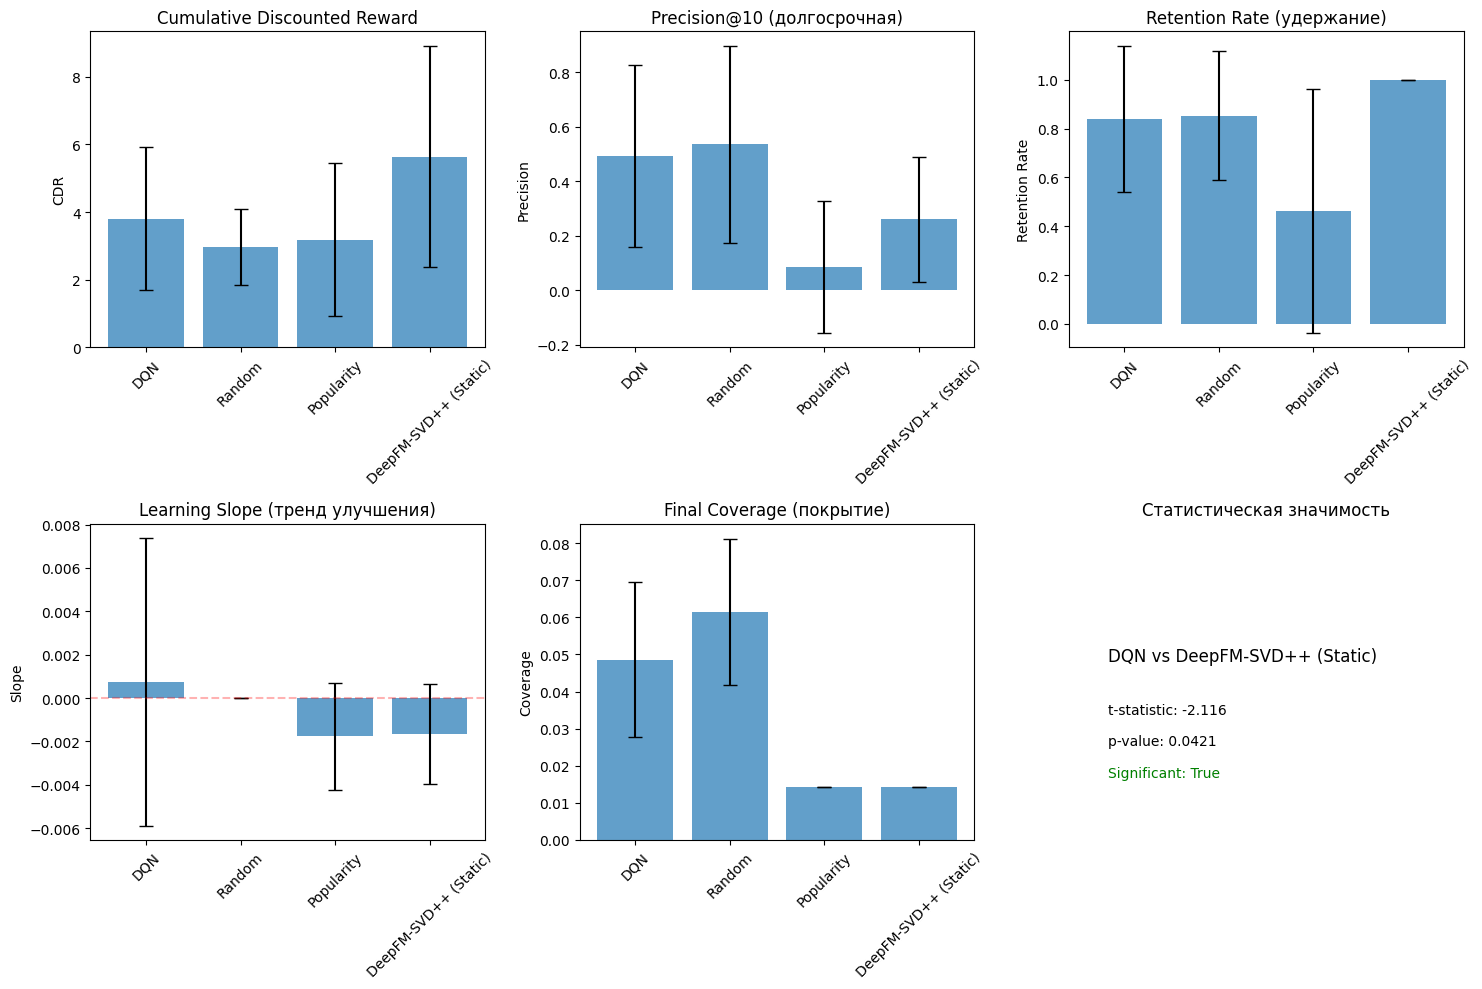

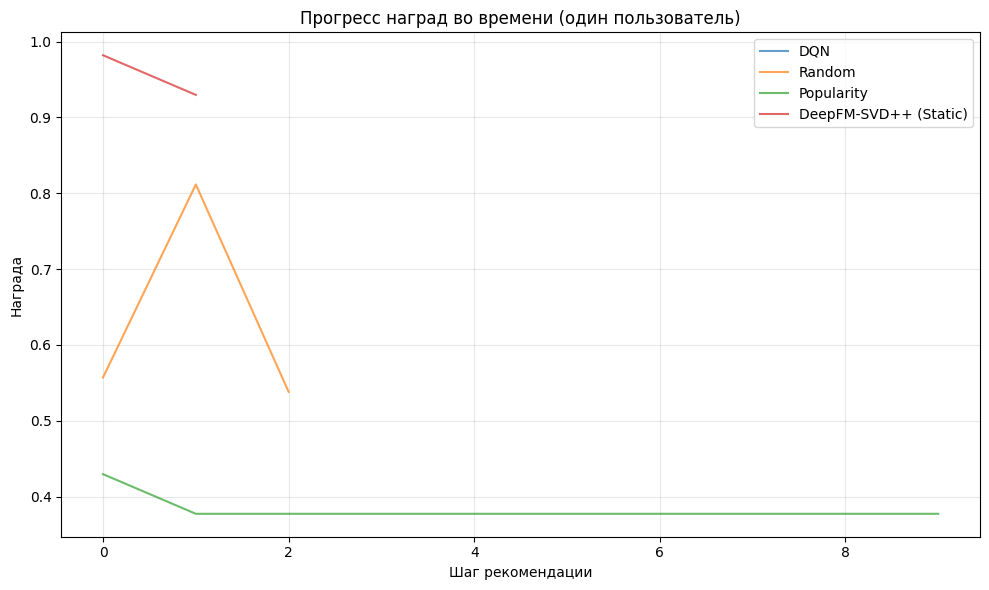


АНАЛИЗ ДОЛГОСРОЧНОЙ ПОЛЕЗНОСТИ

DQN:
  Cumulative Discounted Reward: 3.800 (±2.112)
  Precision@50: 0.493
  Retention Rate: 0.840
  Learning Slope: 0.001 (улучшение)

Random:
  Cumulative Discounted Reward: 2.967 (±1.110)
  Precision@50: 0.536
  Retention Rate: 0.853
  Learning Slope: 0.000 (ухудшение)

Popularity:
  Cumulative Discounted Reward: 3.188 (±2.267)
  Precision@50: 0.086
  Retention Rate: 0.462
  Learning Slope: -0.002 (ухудшение)

DeepFM-SVD++ (Static):
  Cumulative Discounted Reward: 5.637 (±3.259)
  Precision@50: 0.260
  Retention Rate: 1.000
  Learning Slope: -0.002 (ухудшение)


In [19]:
import matplotlib.pyplot as plt
from scipy import stats

class LongTermEvaluator:
    def __init__(self, env, dqn_agent, baseline_models):
        self.env = env
        self.dqn_agent = dqn_agent
        self.baseline_models = baseline_models
        
    def run_long_term_experiment(self, n_users=30, trajectory_length=100):
        """Запуск долгосрочного эксперимента"""
        
        results = {}
        
        for model_name, model in [('DQN', self.dqn_agent)] + list(self.baseline_models.items()):
            print(f"\nТестирование {model_name}...")
            
            user_results = []
            for user_idx in range(n_users):
                # Сброс среды для нового пользователя
                state = self.env.reset(user_id=user_idx)
                
                rewards = []
                recommended_items = []
                relevant_items = []
                
                for step in range(trajectory_length):
                    # Получение рекомендации
                    if model_name == 'DQN':
                        action = model.get_action(state, epsilon=0.01)
                    else:
                        action = model(user_idx, self.env.current_context, k=1)[0]
                    
                    recommended_items.append(action)
                    
                    # Шаг в среде
                    next_state, reward, done, info = self.env.step(action)
                    
                    rewards.append(reward)
                    
                    # Сбор ground truth
                    if reward > 0.7:
                        relevant_items.append(action)
                    
                    state = next_state
                    if done:
                        break
                
                # Расчет метрик для этого пользователя
                user_metrics = self._calculate_user_metrics(
                    recommended_items, relevant_items, rewards, trajectory_length
                )
                user_results.append(user_metrics)
            
            # Агрегация по всем пользователям
            results[model_name] = self._aggregate_results(user_results)
        
        return results
    
    def _calculate_user_metrics(self, recommendations, relevant_items, rewards, trajectory_length):
        """Расчет всех метрик для одного пользователя"""
        
        metrics = {}
        
        # 1. Традиционные метрики (на всей траектории)
        k = min(90, len(recommendations))
        true_positives = len(set(recommendations[:k]) & set(relevant_items))
        
        metrics['Precision@10'] = true_positives / k if k > 0 else 0
        metrics['Recall@10'] = true_positives / len(relevant_items) if relevant_items else 0
        metrics['F1@10'] = 2 * metrics['Precision@10'] * metrics['Recall@10'] / (
            metrics['Precision@10'] + metrics['Recall@10'] + 1e-8
        )
        
        # 2. Долгосрочные метрики
        # Cumulative Discounted Reward (CDR)
        gamma = 0.99
        discounted_rewards = []
        discount = 1.0
        for r in rewards:
            discounted_rewards.append(r * discount)
            discount *= gamma
        
        metrics['CDR'] = sum(discounted_rewards)
        
        # Retention Rate
        metrics['Retention_Rate'] = sum(1 for r in rewards if r > 0.5) / len(rewards)
        
        # Learning Progress (тренд улучшения наград)
        if len(rewards) >= 10:
            segments = np.array_split(rewards, 5)
            segment_means = [np.mean(seg) for seg in segments]
            x = range(len(segment_means))
            slope, _ = np.polyfit(x, segment_means, 1)
            metrics['Learning_Slope'] = slope
        else:
            metrics['Learning_Slope'] = 0
        
        # Coverage прогресс
        coverage_progress = []
        for i in range(1, len(recommendations) + 1):
            coverage_progress.append(len(set(recommendations[:i])) / min(i, self.env.dataset.n_items))
        
        metrics['Coverage_Progress'] = coverage_progress[-1] if coverage_progress else 0
        metrics['Final_Coverage'] = len(set(recommendations)) / self.env.dataset.n_items

        metrics['rewards_progress'] = rewards
        
        return metrics
    
    def _aggregate_results(self, user_results):
        """Агрегация результатов по пользователям"""
        df = pd.DataFrame(user_results)

        cols = ['CDR', 'Precision@10', 'Recall@10', 'F1@10', 'Retention_Rate', 'Learning_Slope', 'Coverage_Progress', 'Final_Coverage']
        return {
            'mean': df[cols].mean(),
            'std': df[cols].std(),
            'data': df
        }
    
    def visualize_long_term_results(self, results):
        """Визуализация долгосрочных результатов"""
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        models = list(results.keys())
        
        # 1. Cumulative Discounted Reward
        cdrs = [results[m]['mean']['CDR'] for m in models]
        cdrs_std = [results[m]['std']['CDR'] for m in models]
        
        axes[0, 0].bar(models, cdrs, yerr=cdrs_std, capsize=5, alpha=0.7)
        axes[0, 0].set_title('Cumulative Discounted Reward')
        axes[0, 0].set_ylabel('CDR')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # 2. Precision@50
        precisions = [results[m]['mean']['Precision@10'] for m in models]
        precisions_std = [results[m]['std']['Precision@10'] for m in models]
        
        axes[0, 1].bar(models, precisions, yerr=precisions_std, capsize=5, alpha=0.7)
        axes[0, 1].set_title('Precision@10 (долгосрочная)')
        axes[0, 1].set_ylabel('Precision')
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # 3. Retention Rate
        retentions = [results[m]['mean']['Retention_Rate'] for m in models]
        retentions_std = [results[m]['std']['Retention_Rate'] for m in models]
        
        axes[0, 2].bar(models, retentions, yerr=retentions_std, capsize=5, alpha=0.7)
        axes[0, 2].set_title('Retention Rate (удержание)')
        axes[0, 2].set_ylabel('Retention Rate')
        axes[0, 2].tick_params(axis='x', rotation=45)
        
        # 4. Learning Slope
        slopes = [results[m]['mean']['Learning_Slope'] for m in models]
        slopes_std = [results[m]['std']['Learning_Slope'] for m in models]
        
        axes[1, 0].bar(models, slopes, yerr=slopes_std, capsize=5, alpha=0.7)
        axes[1, 0].set_title('Learning Slope (тренд улучшения)')
        axes[1, 0].set_ylabel('Slope')
        axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # 5. Final Coverage
        coverages = [results[m]['mean']['Final_Coverage'] for m in models]
        coverages_std = [results[m]['std']['Final_Coverage'] for m in models]
        
        axes[1, 1].bar(models, coverages, yerr=coverages_std, capsize=5, alpha=0.7)
        axes[1, 1].set_title('Final Coverage (покрытие)')
        axes[1, 1].set_ylabel('Coverage')
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        # 6. Статистическая значимость различий
        # Сравнение DQN с лучшим базовым методом
        best_baseline = max(['Random', 'Popularity', 'DeepFM-SVD++ (Static)'], 
                           key=lambda x: results[x]['mean']['CDR'])
        
        dqn_data = results['DQN']['data']['CDR']
        baseline_data = results[best_baseline]['data']['CDR']
        
        # T-test для статистической значимости
        t_stat, p_value = stats.ttest_ind(dqn_data, baseline_data, equal_var=False)
        
        axes[1, 2].text(0.1, 0.5, f'DQN vs {best_baseline}\n', fontsize=12)
        axes[1, 2].text(0.1, 0.4, f't-statistic: {t_stat:.3f}', fontsize=10)
        axes[1, 2].text(0.1, 0.3, f'p-value: {p_value:.4f}', fontsize=10)
        axes[1, 2].text(0.1, 0.2, f'Significant: {p_value < 0.05}', fontsize=10, 
                       color='green' if p_value < 0.05 else 'red')
        axes[1, 2].set_title('Статистическая значимость')
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Дополнительный график: прогресс наград во времени
        fig, ax = plt.subplots(figsize=(10, 6))
        
        for model_name in models:
            # Берем случайного пользователя для визуализации
            user_data = results[model_name]['data'].iloc[0]
            
            if 'rewards_progress' in user_data:
                rewards_progress = user_data['rewards_progress']
                ax.plot(rewards_progress, label=model_name, alpha=0.7)
        
        ax.set_xlabel('Шаг рекомендации')
        ax.set_ylabel('Награда')
        ax.set_title('Прогресс наград во времени (один пользователь)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Запуск долгосрочной оценки
print("Запуск долгосрочной оценки полезности...")

long_term_evaluator = LongTermEvaluator(
    env=env,
    dqn_agent=dqn_agent,
    baseline_models={
        'Random': tester.random_recommender,
        'Popularity': tester.popularity_recommender,
        'DeepFM-SVD++ (Static)': tester.static_deepfm_recommender
    }
)

long_term_results = long_term_evaluator.run_long_term_experiment(
    n_users=20,
    trajectory_length=100
)

print("\nВизуализация долгосрочных результатов...")
long_term_evaluator.visualize_long_term_results(long_term_results)

# Анализ результатов
print("\n" + "="*60)
print("АНАЛИЗ ДОЛГОСРОЧНОЙ ПОЛЕЗНОСТИ")
print("="*60)

for model_name, results in long_term_results.items():
    mean = results['mean']
    print(f"\n{model_name}:")
    print(f"  Cumulative Discounted Reward: {mean['CDR']:.3f} (±{results['std']['CDR']:.3f})")
    print(f"  Precision@50: {mean['Precision@10']:.3f}")
    print(f"  Retention Rate: {mean['Retention_Rate']:.3f}")
    print(f"  Learning Slope: {mean['Learning_Slope']:.3f} {'(улучшение)' if mean['Learning_Slope'] > 0 else '(ухудшение)'}")